# 💳 Credit Card Customer Segmentation — Unsupervised Learning

**Practical Exam – Set C | Role:** Junior Data Scientist, Credit Cards Division of an Indian private bank

**Goal:** Group ~8,950 active cardholders into behavioural segments using three clustering algorithms
(**K-Means, Agglomerative Hierarchical, DBSCAN**), compare them with internal metrics, and turn the clusters
into business personas the Relationship Managers can act on.

**Dataset:** `CC_GENERAL.csv` — [Kaggle: Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

| Step | Content |
|---|---|
| 1 | Loading, cleaning & Exploratory Data Analysis |
| 2 | Feature engineering, outlier capping, log transform, scaling |
| 3 | K-Means (Elbow + Silhouette) |
| 4 | Agglomerative Hierarchical (Dendrogram + 3 linkages) |
| 5 | DBSCAN (k-NN distance plot + grid search) |
| 6 | Algorithm comparison, stability check, business recommendation |
| 7 | Saving the pipeline + `predict_segment()` |

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import joblib

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

# all plots are also saved in /images so they can be used as screenshots in the README
os.makedirs('images', exist_ok=True)
def save_fig(name):
    plt.savefig(f'images/{name}.png', dpi=130, bbox_inches='tight')

PALETTE = ['#e63946', '#1d9bf0', '#2a9d8f', '#f4a261', '#9b5de5', '#fb6f92', '#8d99ae', '#06d6a0']
print('Libraries loaded')

Libraries loaded


---
# 📂 Step 1: Dataset Loading & Exploratory Data Analysis
## 1.1 Load & Inspect the Dataset

In [2]:
cc = pd.read_csv('CC_GENERAL.csv')
print('Shape:', cc.shape)
print()
cc.info()

Shape: (8950, 18)

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12

In [3]:
cc.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [4]:
# CUST_ID is only an identifier, not a behavioural feature -> drop it
cc = cc.drop(columns=['CUST_ID'])
print('Shape after dropping CUST_ID:', cc.shape)

# missing values in every column
print('\nMissing values per column:')
print(cc.isnull().sum())

Shape after dropping CUST_ID: (8950, 17)

Missing values per column:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [5]:
# impute CREDIT_LIMIT and MINIMUM_PAYMENTS with their column medians
n_cl = cc['CREDIT_LIMIT'].isnull().sum()
n_mp = cc['MINIMUM_PAYMENTS'].isnull().sum()

cc['CREDIT_LIMIT'] = cc['CREDIT_LIMIT'].fillna(cc['CREDIT_LIMIT'].median())
cc['MINIMUM_PAYMENTS'] = cc['MINIMUM_PAYMENTS'].fillna(cc['MINIMUM_PAYMENTS'].median())

print('Imputed CREDIT_LIMIT      :', n_cl, 'value(s) with median')
print('Imputed MINIMUM_PAYMENTS  :', n_mp, 'values with median')
print('Total values imputed      :', n_cl + n_mp)
print('Missing values left       :', cc.isnull().sum().sum())

# duplicate rows
print('\nDuplicate rows:', cc.duplicated().sum())

Imputed CREDIT_LIMIT      : 1 value(s) with median
Imputed MINIMUM_PAYMENTS  : 313 values with median
Total values imputed      : 314
Missing values left       : 0

Duplicate rows: 0


**Observation:** Only two columns had missing data — `CREDIT_LIMIT` (1 value) and `MINIMUM_PAYMENTS` (313 values).
Both are right-skewed money columns, so the **median** is a safer filler than the mean. There are **no duplicate rows**.

## 1.2 Univariate Analysis

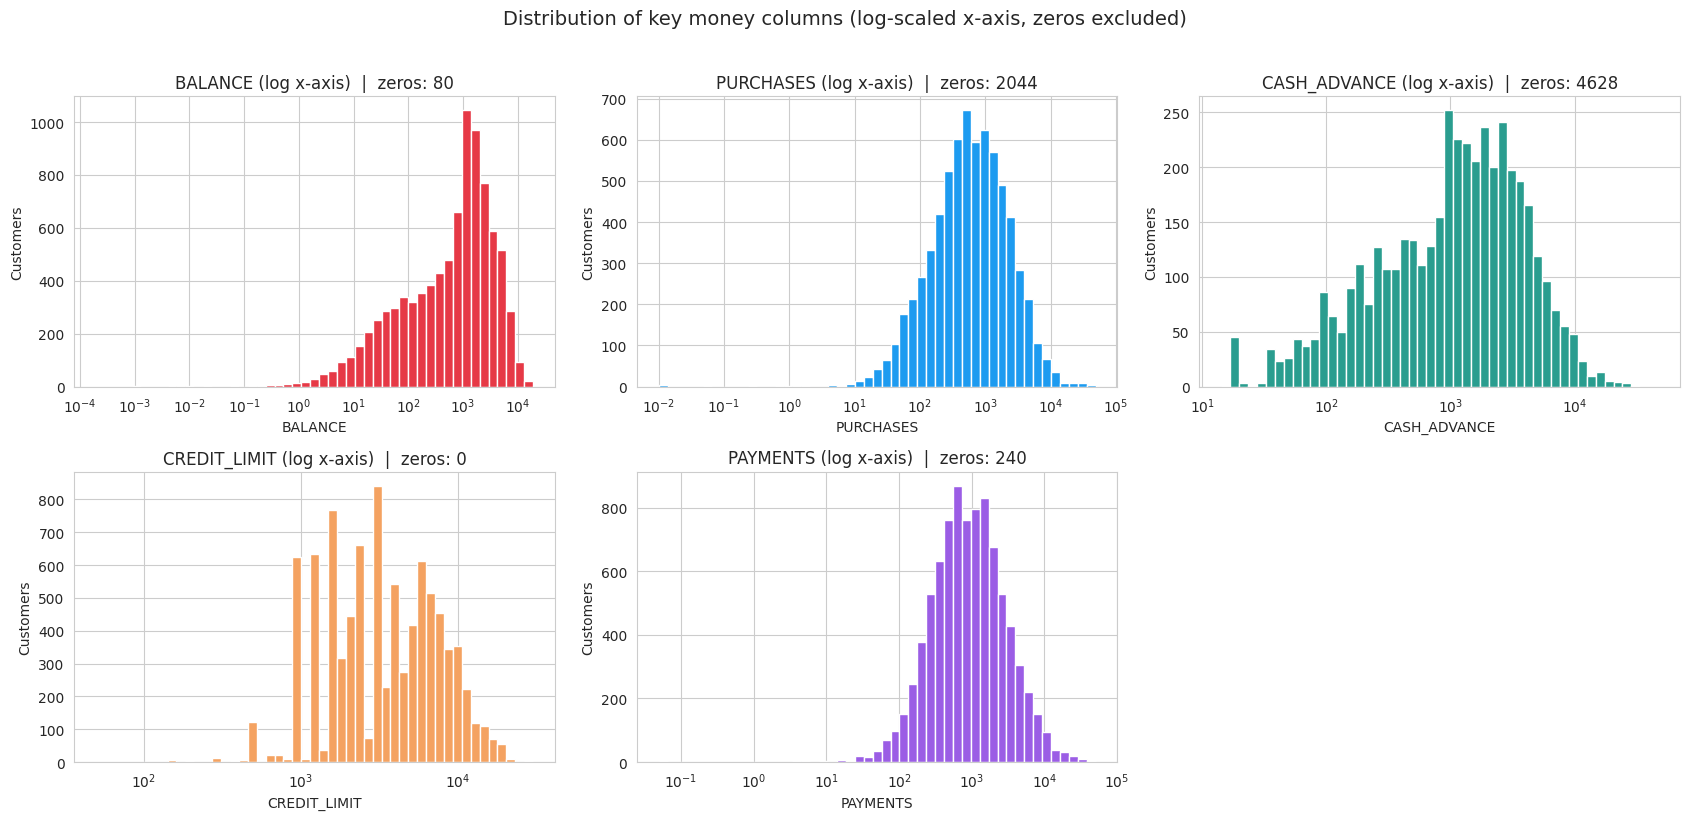

In [6]:
hist_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, col in zip(axes.flat, hist_cols):
    data = cc[col][cc[col] > 0]            # log axis cannot show zeros
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
    ax.hist(data, bins=bins, color=PALETTE[hist_cols.index(col)], edgecolor='white')
    ax.set_xscale('log')
    ax.set_title(f'{col} (log x-axis)  |  zeros: {(cc[col]==0).sum()}')
    ax.set_xlabel(col); ax.set_ylabel('Customers')
axes.flat[-1].axis('off')
plt.suptitle('Distribution of key money columns (log-scaled x-axis, zeros excluded)', fontsize=14, y=1.02)
plt.tight_layout()
save_fig('01_histograms_log')
plt.show()

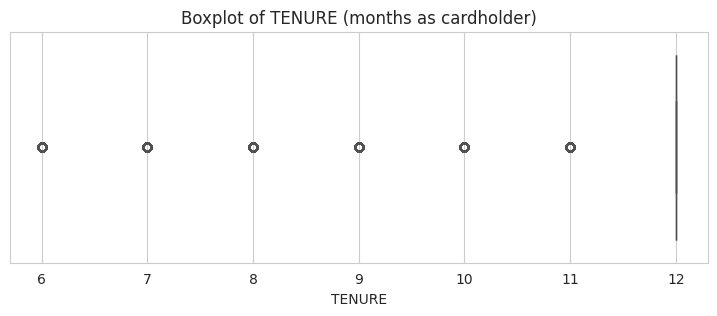

TENURE
6      204
7      190
8      196
9      175
10     236
11     365
12    7584
Name: count, dtype: int64

% customers with TENURE = 12 : 84.7


In [7]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=cc['TENURE'], color='#1d9bf0')
plt.title('Boxplot of TENURE (months as cardholder)')
save_fig('02_tenure_boxplot')
plt.show()

print(cc['TENURE'].value_counts().sort_index())
print('\n% customers with TENURE = 12 :', round((cc['TENURE'] == 12).mean() * 100, 1))

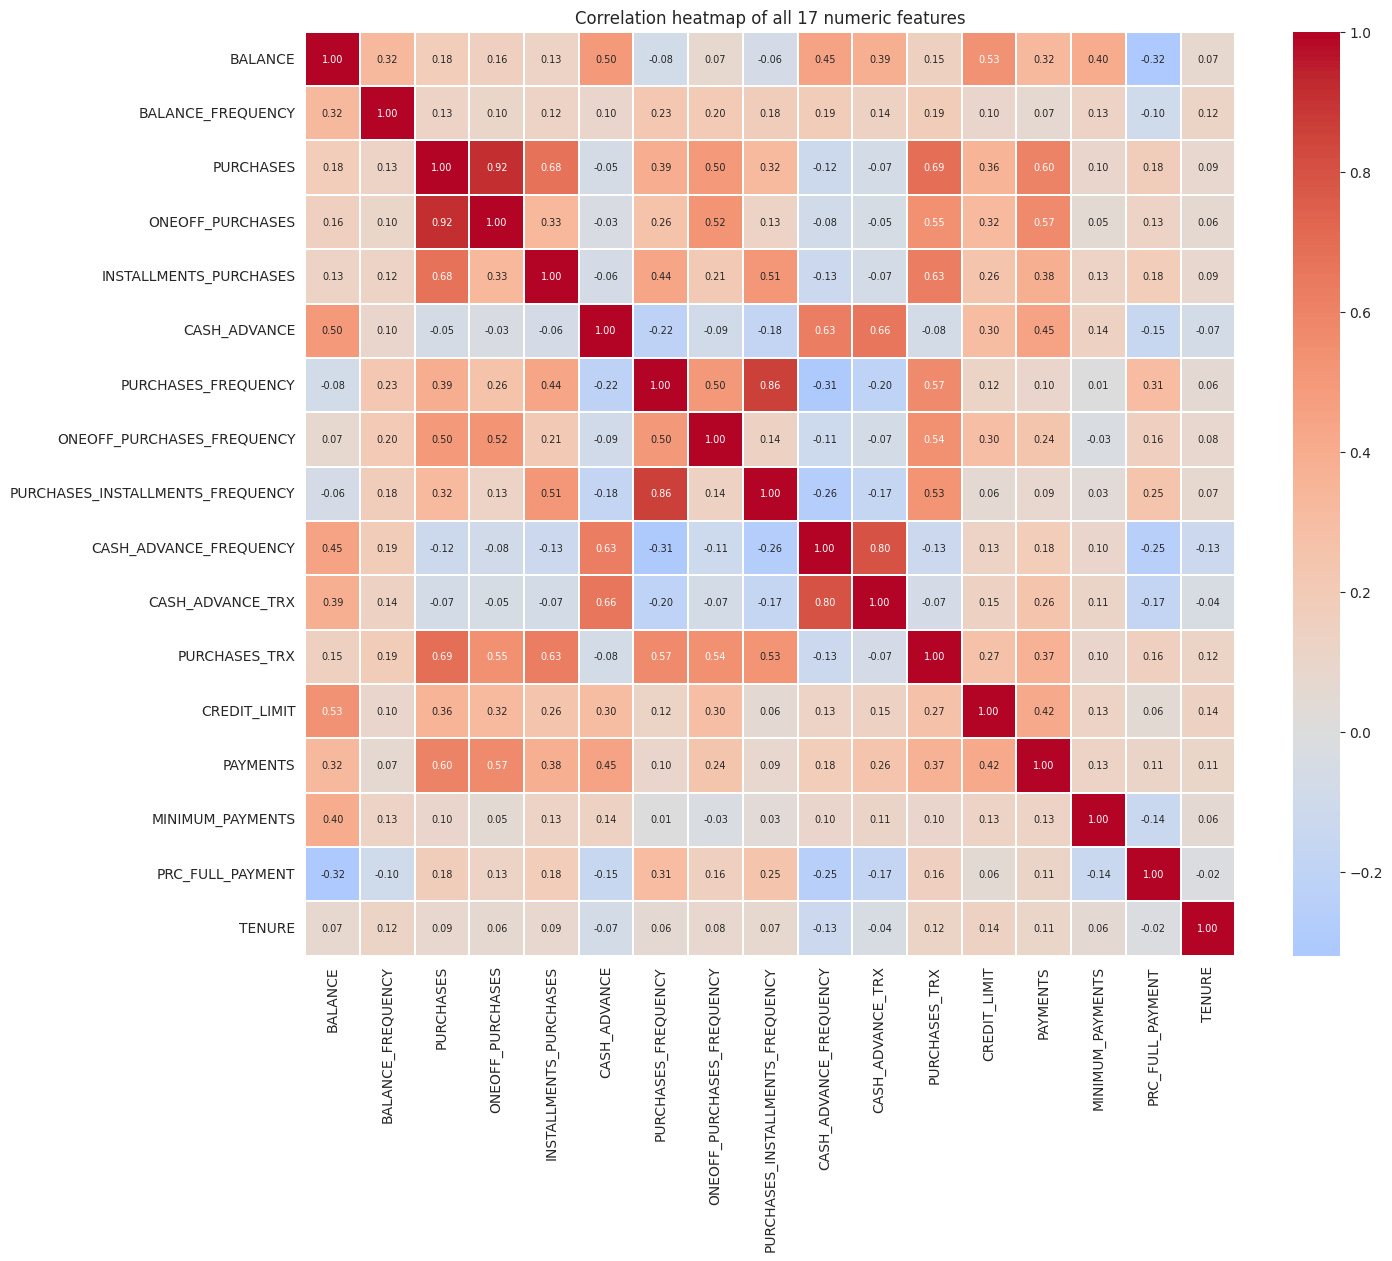

Highly correlated feature pairs (|r| > 0.7):
PURCHASES               ONEOFF_PURCHASES                    0.92
PURCHASES_FREQUENCY     PURCHASES_INSTALLMENTS_FREQUENCY    0.86
CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX                    0.80
dtype: float64


In [8]:
plt.figure(figsize=(15, 12))
corr = cc.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7}, linewidths=.3)
plt.title('Correlation heatmap of all 17 numeric features')
save_fig('03_correlation_heatmap')
plt.show()

# list the strongly correlated pairs (|r| > 0.7)
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strong = pairs[pairs.abs() > 0.7].sort_values(ascending=False)
print('Highly correlated feature pairs (|r| > 0.7):')
print(strong.round(2))

**Observation:** Only three pairs cross |r| > 0.7, and all follow banking logic:
`PURCHASES` ↔ `ONEOFF_PURCHASES` (0.92), `PURCHASES_FREQUENCY` ↔ `PURCHASES_INSTALLMENTS_FREQUENCY` (0.86) and
`CASH_ADVANCE_FREQUENCY` ↔ `CASH_ADVANCE_TRX` (0.80). Many other purchase-related columns are also moderately correlated with each other,
which shows that "spending behaviour" and "cash-advance behaviour" are two fairly separate dimensions of the data — exactly what clustering should pick up.

## 1.3 Customer-Level Analysis

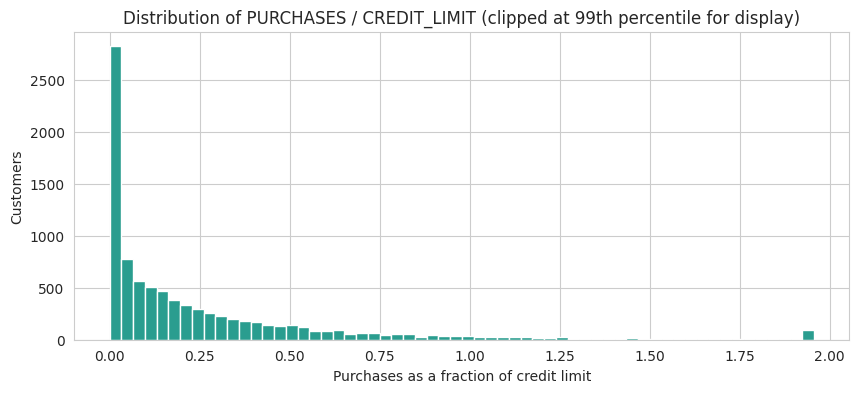

count    8950.000
mean        0.263
std         0.437
min         0.000
25%         0.011
50%         0.117
75%         0.338
max         8.591
dtype: float64


In [9]:
# rough utilisation measure: PURCHASES / CREDIT_LIMIT
purchase_util = cc['PURCHASES'] / cc['CREDIT_LIMIT']

plt.figure(figsize=(10, 4))
plt.hist(purchase_util.clip(upper=purchase_util.quantile(0.99)), bins=60, color='#2a9d8f', edgecolor='white')
plt.title('Distribution of PURCHASES / CREDIT_LIMIT (clipped at 99th percentile for display)')
plt.xlabel('Purchases as a fraction of credit limit'); plt.ylabel('Customers')
save_fig('04_purchase_utilisation')
plt.show()
print(purchase_util.describe().round(3))

In [10]:
# top 10 customers by CASH_ADVANCE
top10 = cc.nlargest(10, 'CASH_ADVANCE')[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']]
display(top10)

print('Average PURCHASES of top-10 cash-advance customers :', round(top10['PURCHASES'].mean(), 1))
print('Average PURCHASES of all customers                 :', round(cc['PURCHASES'].mean(), 1))
print('Median  PURCHASES of all customers                 :', round(cc['PURCHASES'].median(), 1))
print('Top-10 customers with PURCHASES above the overall median:', (top10['PURCHASES'] > cc['PURCHASES'].median()).sum(), 'out of 10')

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY
2159,10905.053810,431.93,47137.21176,19600.0,39048.59762,0.583333
1059,8823.284205,3719.00,29282.10915,15500.0,28150.97869,1.000000
71,2990.422186,4523.27,27296.48576,7000.0,28232.69446,0.666667
7254,4530.205197,1750.66,26268.69989,8500.0,25203.91336,1.000000
7645,7081.171387,0.00,26194.04954,9000.0,20191.30770,0.000000
2454,10915.550750,0.00,23130.82106,15000.0,18341.95467,0.000000
883,14581.459140,0.00,22665.77850,18500.0,20941.32551,0.000000
6371,4529.895962,0.00,21943.84942,13000.0,33486.31044,0.000000
3806,14100.251100,4995.80,20712.67008,16500.0,20418.33238,1.000000
6455,9110.968989,1490.75,20277.33112,11000.0,19740.74802,0.166667


Average PURCHASES of top-10 cash-advance customers : 1691.1
Average PURCHASES of all customers                 : 1003.2
Median  PURCHASES of all customers                 : 361.3
Top-10 customers with PURCHASES above the overall median: 6 out of 10


Customers with PURCHASES == 0 : 2044  (22.84%)
Customers needed to reach 80% of total purchase volume: 2346 (26.2% of customers)


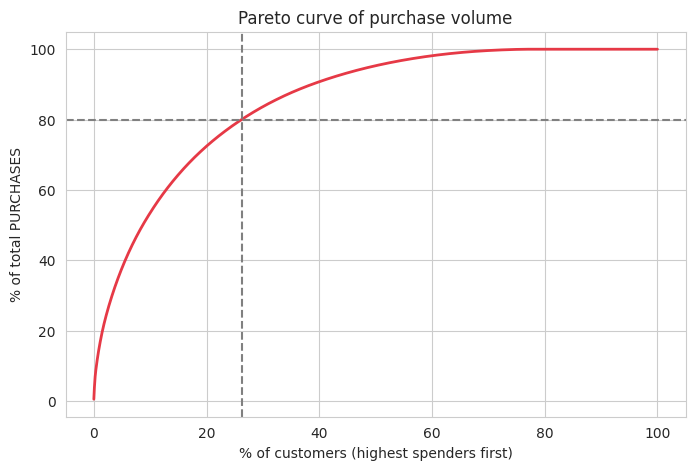

In [11]:
# % of customers who never made a purchase
never = (cc['PURCHASES'] == 0).mean() * 100
print(f'Customers with PURCHASES == 0 : {(cc["PURCHASES"] == 0).sum()}  ({never:.2f}%)')

# Pareto / 80-20 check on total PURCHASES
sorted_p = cc['PURCHASES'].sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_p.cumsum() / sorted_p.sum()
n80 = int((cum_share < 0.80).sum() + 1)
print(f'Customers needed to reach 80% of total purchase volume: {n80} ({n80 / len(cc) * 100:.1f}% of customers)')

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cc) + 1) / len(cc) * 100, cum_share * 100, color='#e63946', lw=2)
plt.axhline(80, color='grey', ls='--'); plt.axvline(n80 / len(cc) * 100, color='grey', ls='--')
plt.xlabel('% of customers (highest spenders first)'); plt.ylabel('% of total PURCHASES')
plt.title('Pareto curve of purchase volume')
save_fig('05_pareto_curve')
plt.show()

**Observations**
- About **22.8%** of customers (2,044) have **never made a purchase** — they either use the card only for cash advances or hardly use it at all.
- The top-10 cash-advance customers are a **mixed group, not one type**: 4 of the 10 made **zero purchases** (pure cash-advance users), while others are also heavy spenders (up to about ₹5,000 purchases).
  What they all share is a **large credit limit** (₹7,000 – ₹19,600) and very large payments. So extreme cash-advance usage is not the same thing as low spending — which is why clustering on several features together is needed.
- The **Pareto principle holds**: only about **26% of customers** generate **80%** of the total purchase volume (roughly an 80/26 rule rather than exactly 80/20) — a minority of cardholders drives most of the spend.

---
# 🔧 Step 2: Feature Engineering & Preprocessing
## 2.1 Engineer Behavioural Features

In [12]:
fe = cc.copy()                       # fe = feature-engineered DataFrame (original, unscaled values)

fe['Monthly_Avg_Purchase']        = fe['PURCHASES'] / fe['TENURE']
fe['Monthly_Avg_Cash_Advance']    = fe['CASH_ADVANCE'] / fe['TENURE']
# guard against divide-by-zero: if CREDIT_LIMIT is 0 the ratio is set to 0
fe['Limit_Usage']                 = (fe['BALANCE'] / fe['CREDIT_LIMIT'].replace(0, np.nan)).fillna(0)
fe['Payment_to_Minpayment_Ratio'] = fe['PAYMENTS'] / (fe['MINIMUM_PAYMENTS'] + 1)

new_cols = ['Monthly_Avg_Purchase', 'Monthly_Avg_Cash_Advance', 'Limit_Usage', 'Payment_to_Minpayment_Ratio']

print('Feature-engineered DataFrame (one row per customer):', fe.shape)
display(fe.head(10))

Feature-engineered DataFrame (one row per customer): (8950, 21)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,7.950000,0.000000,0.040901,1.436214
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0.000000,536.912124,0.457495,3.822677
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,64.430833,0.000000,0.332687,0.990103
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,124.916667,17.149001,0.222223,0.000000
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1.333333,0.000000,0.681429,2.759800
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,111.106667,0.000000,1.005460,0.581360
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12,590.917500,0.000000,0.046464,31.920658
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,36.350000,0.000000,0.792892,1.273962
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,71.790833,0.000000,0.144989,2.199230
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,106.800000,0.000000,0.013839,11.497972


In [13]:
display(fe[new_cols].describe().round(3))

skew_tbl = pd.DataFrame({'min': fe[new_cols].min(), 'max': fe[new_cols].max(),
                         'skewness': fe[new_cols].skew()}).round(2)
print('Range and skewness of the new features:')
display(skew_tbl)

,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
count,8950.000,8950.000,8950.000,8950.000
mean,86.175,88.978,0.389,6.391
std,180.509,193.136,0.390,31.995
min,0.000,0.000,0.000,0.000
25%,3.399,0.000,0.041,0.911
50%,31.937,0.000,0.303,2.017
75%,97.228,99.085,0.718,6.014
max,4086.631,3928.101,15.910,1863.850


Range and skewness of the new features:


,min,max,skewness
Monthly_Avg_Purchase,0.0,4086.63,8.00
Monthly_Avg_Cash_Advance,0.0,3928.10,4.94
Limit_Usage,0.0,15.91,7.42
Payment_to_Minpayment_Ratio,0.0,1863.85,36.90


**Observation:** All four engineered features are **strongly right-skewed** (a few customers have huge values while most are small).
`Payment_to_Minpayment_Ratio` has the widest range (it explodes when `MINIMUM_PAYMENTS` is tiny), whereas `Limit_Usage` is the most
well-behaved because it is a ratio that mostly stays between 0 and 1. This tells us we must cap outliers and use a log transform before clustering.

## 2.2 Handle Outliers (IQR capping / winsorization)

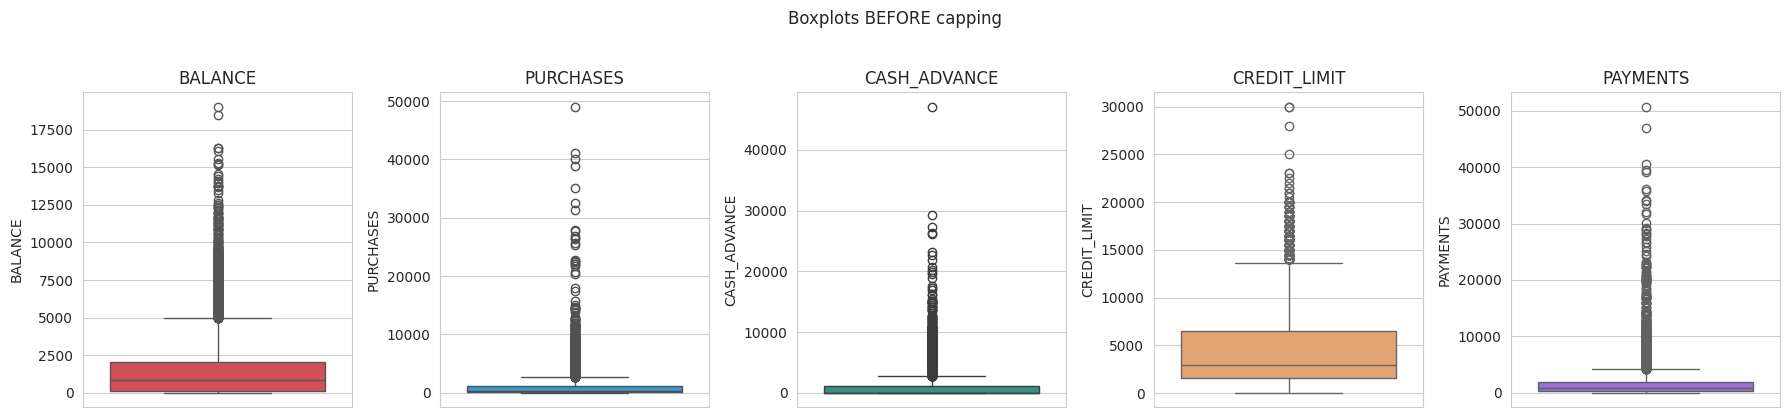

In [14]:
box_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, box_cols):
    sns.boxplot(y=fe[col], ax=ax, color=PALETTE[box_cols.index(col)])
    ax.set_title(col)
plt.suptitle('Boxplots BEFORE capping', y=1.03)
plt.tight_layout()
save_fig('06_boxplots_before')
plt.show()

In [15]:
# money columns + engineered columns are all right-skewed -> cap all of them (not only the 5 plotted)
money_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
              'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
              'Monthly_Avg_Purchase', 'Monthly_Avg_Cash_Advance', 'Payment_to_Minpayment_Ratio']
cap_cols = money_cols + ['Limit_Usage']

fe_cap = fe.copy()
cap_limits = {}
rows = []
for col in cap_cols:
    q1, q3 = fe[col].quantile([0.25, 0.75])
    upper = q3 + 3 * (q3 - q1)                  # extreme-outlier threshold = Q3 + 3*IQR
    cap_limits[col] = upper
    n_out = int((fe[col] > upper).sum())
    fe_cap[col] = fe[col].clip(upper=upper)     # winsorize: cap, do not drop rows
    rows.append([col, round(upper, 2), n_out, round(n_out / len(fe) * 100, 2)])

display(pd.DataFrame(rows, columns=['Column', 'Cap (Q3+3*IQR)', 'Extreme outliers capped', '% of rows']))
print('Rows before capping:', len(fe), '| rows after capping:', len(fe_cap), '(no rows dropped)')

,Column,Cap (Q3+3*IQR),Extreme outliers capped,% of rows
0,BALANCE,7831.71,194,2.17
1,PURCHASES,4321.62,391,4.37
2,ONEOFF_PURCHASES,2309.62,566,6.32
3,INSTALLMENTS_PURCHASES,1874.55,395,4.41
4,CASH_ADVANCE,4455.28,486,5.43
5,CREDIT_LIMIT,21200.00,10,0.11
6,PAYMENTS,6454.71,402,4.49
7,MINIMUM_PAYMENTS,2642.28,470,5.25
8,Monthly_Avg_Purchase,378.72,363,4.06
9,Monthly_Avg_Cash_Advance,396.34,511,5.71


Rows before capping: 8950 | rows after capping: 8950 (no rows dropped)


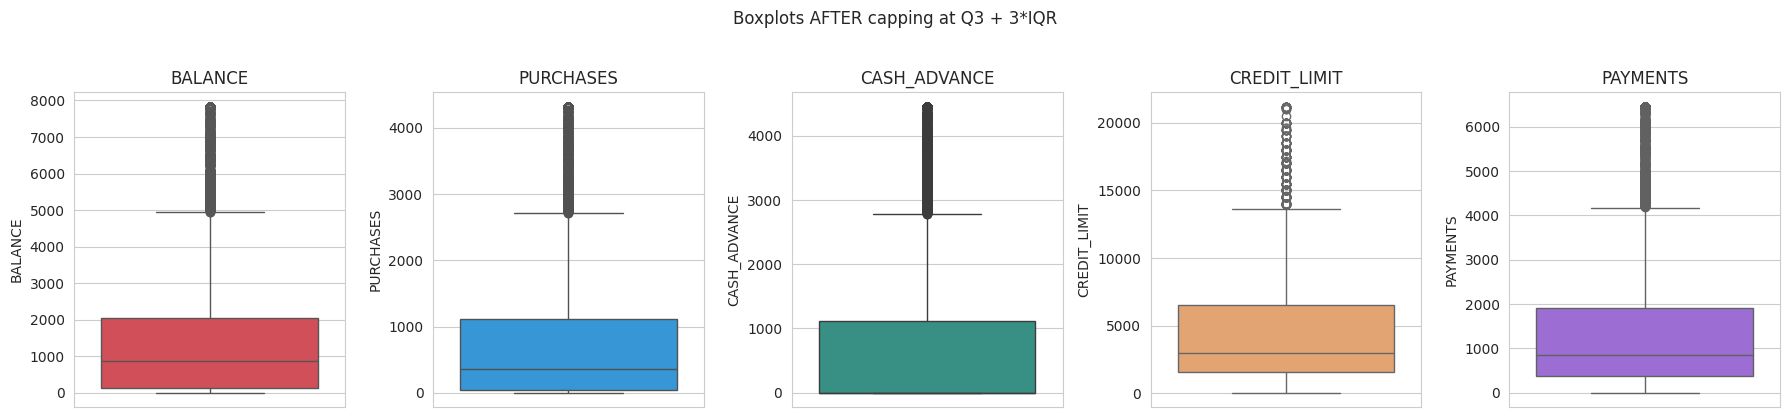

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, box_cols):
    sns.boxplot(y=fe_cap[col], ax=ax, color=PALETTE[box_cols.index(col)])
    ax.set_title(col)
plt.suptitle('Boxplots AFTER capping at Q3 + 3*IQR', y=1.03)
plt.tight_layout()
save_fig('07_boxplots_after')
plt.show()

**Observation:** Before capping, a handful of customers had balances, purchases or cash advances many times larger than everyone else
(visible as long tails of dots). After winsorization the extreme tail is pulled in to the `Q3 + 3*IQR` threshold while all rows are kept,
so the big spenders are still in the data but can no longer dominate the distance calculations.

## 2.3 Transform Skewed Features (log1p)

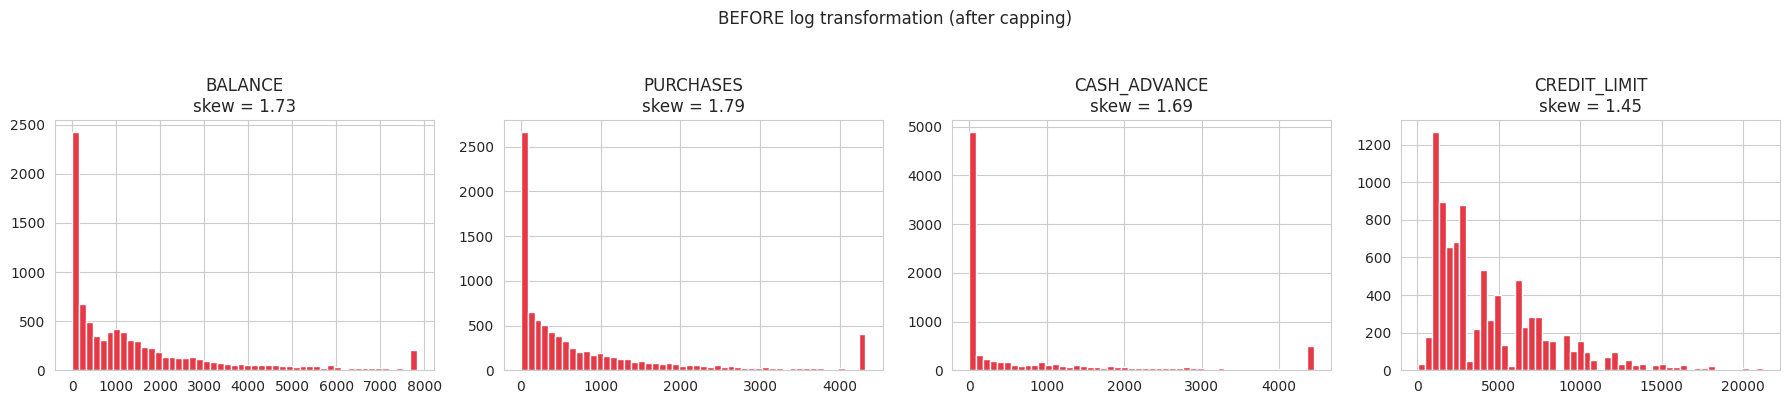

In [17]:
hist4 = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col in zip(axes, hist4):
    ax.hist(fe_cap[col], bins=50, color='#e63946', edgecolor='white')
    ax.set_title(f'{col}\nskew = {fe_cap[col].skew():.2f}')
plt.suptitle('BEFORE log transformation (after capping)', y=1.05)
plt.tight_layout()
save_fig('08_hist_before_log')
plt.show()

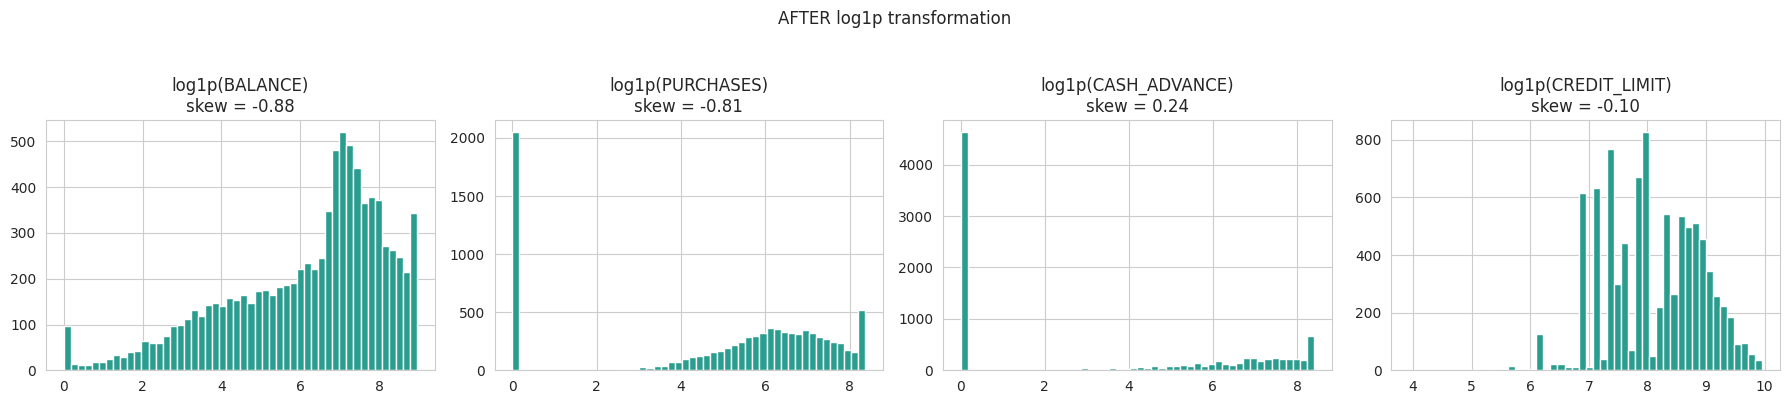

,skew before,skew after
BALANCE,1.73,-0.88
PURCHASES,1.79,-0.81
ONEOFF_PURCHASES,1.71,0.14
INSTALLMENTS_PURCHASES,1.76,-0.05
CASH_ADVANCE,1.69,0.24
CREDIT_LIMIT,1.45,-0.10
PAYMENTS,1.73,-1.98
MINIMUM_PAYMENTS,1.72,-0.15
Monthly_Avg_Purchase,1.80,-0.41
Monthly_Avg_Cash_Advance,1.69,0.40


In [18]:
fe_log = fe_cap.copy()
fe_log[money_cols] = np.log1p(fe_log[money_cols])      # log1p handles zeros safely

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col in zip(axes, hist4):
    ax.hist(fe_log[col], bins=50, color='#2a9d8f', edgecolor='white')
    ax.set_title(f'log1p({col})\nskew = {fe_log[col].skew():.2f}')
plt.suptitle('AFTER log1p transformation', y=1.05)
plt.tight_layout()
save_fig('09_hist_after_log')
plt.show()

skew_cmp = pd.DataFrame({'skew before': fe_cap[money_cols].skew(), 'skew after': fe_log[money_cols].skew()}).round(2)
display(skew_cmp)

**Observation:** Yes — the distributions are much more symmetrical after `log1p`. Skewness of the money columns drops from about +1.5 to +1.8 to mostly between -1 and +0.6
(e.g. `CREDIT_LIMIT` 1.45 → -0.10). `PAYMENTS` slightly over-corrects to a left skew (-1.98) because of customers with tiny payments, but it is still far better behaved than before.
`PURCHASES` and `CASH_ADVANCE` still show a spike at 0 because many customers genuinely have no purchases or no cash advances — that is real behaviour, not a data problem.

## 2.4 Scale the Features

In [19]:
scaler = StandardScaler()
cc_scaled = pd.DataFrame(scaler.fit_transform(fe_log), columns=fe_log.columns)   # 17 raw + 4 engineered = 21 features
X = cc_scaled.values

print('cc_scaled shape:', cc_scaled.shape)
check = pd.DataFrame({'mean': cc_scaled.mean().round(6), 'std': cc_scaled.std(ddof=0).round(6)})
display(check)

cc_scaled shape: (8950, 21)


,mean,std
BALANCE,0.0,1.0
BALANCE_FREQUENCY,0.0,1.0
PURCHASES,-0.0,1.0
ONEOFF_PURCHASES,-0.0,1.0
INSTALLMENTS_PURCHASES,0.0,1.0
CASH_ADVANCE,0.0,1.0
PURCHASES_FREQUENCY,-0.0,1.0
ONEOFF_PURCHASES_FREQUENCY,-0.0,1.0
PURCHASES_INSTALLMENTS_FREQUENCY,0.0,1.0
CASH_ADVANCE_FREQUENCY,0.0,1.0


Components for 90% variance: 9  |  for 95% variance: 12  (out of 21)


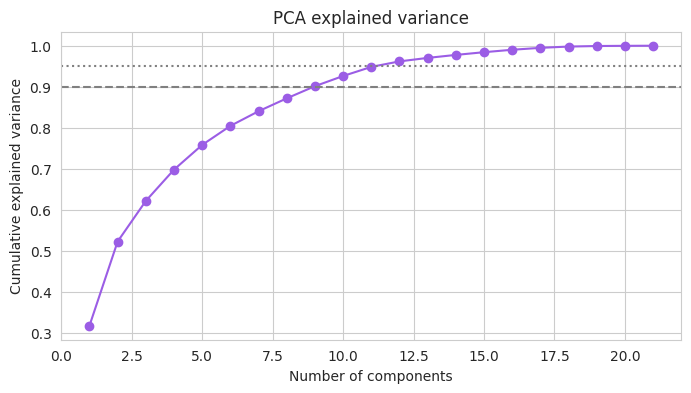

In [20]:
# Optional PCA: how many components would be needed to keep 90-95% of the variance?
pca_full = PCA().fit(X)
cum_var = pca_full.explained_variance_ratio_.cumsum()
n90 = int(np.argmax(cum_var >= 0.90) + 1)
n95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f'Components for 90% variance: {n90}  |  for 95% variance: {n95}  (out of {X.shape[1]})')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='#9b5de5')
plt.axhline(0.90, color='grey', ls='--'); plt.axhline(0.95, color='grey', ls=':')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance'); plt.title('PCA explained variance')
save_fig('10_pca_variance')
plt.show()

**Decision on PCA:** PCA would keep 90% of the variance with only about 9 components, but I **cluster on the full 21 scaled features** instead.
The reasons: (1) 21 features is small enough for all three algorithms, (2) it keeps every cluster directly interpretable in business terms,
and (3) the saved pipeline (`scaler` → `model`) stays simple to deploy in `predict_segment()`. PCA is only used here as a diagnostic.

---
# 🔵 Step 3: K-Means Clustering
## 3.1 Elbow Method & Silhouette Score — Find Optimal k

In [21]:
k_values = list(range(2, 11))
inertias, sil_scores = [], []

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

k_table = pd.DataFrame({'k': k_values, 'WCSS (inertia)': np.round(inertias, 0), 'Silhouette': np.round(sil_scores, 4)})
display(k_table)

# locate the elbow numerically = point furthest from the straight line joining first and last point
pts = np.column_stack([k_values, inertias]).astype(float)
v = (pts[-1] - pts[0]) / np.linalg.norm(pts[-1] - pts[0])
w = pts - pts[0]
dist_to_line = np.abs(w[:, 0] * v[1] - w[:, 1] * v[0])
k_elbow = k_values[int(dist_to_line.argmax())]
k_best_sil = k_values[int(np.argmax(sil_scores))]
print('Elbow detected at k =', k_elbow)
print('Highest silhouette at k =', k_best_sil, f'({max(sil_scores):.4f})')

,k,WCSS (inertia),Silhouette
0,2,142990.0,0.2362
1,3,123095.0,0.2095
2,4,111553.0,0.1965
3,5,102585.0,0.1924
4,6,95071.0,0.1972
5,7,90738.0,0.1965
6,8,87107.0,0.1815
7,9,83675.0,0.1794
8,10,80476.0,0.1818


Elbow detected at k = 5
Highest silhouette at k = 2 (0.2362)


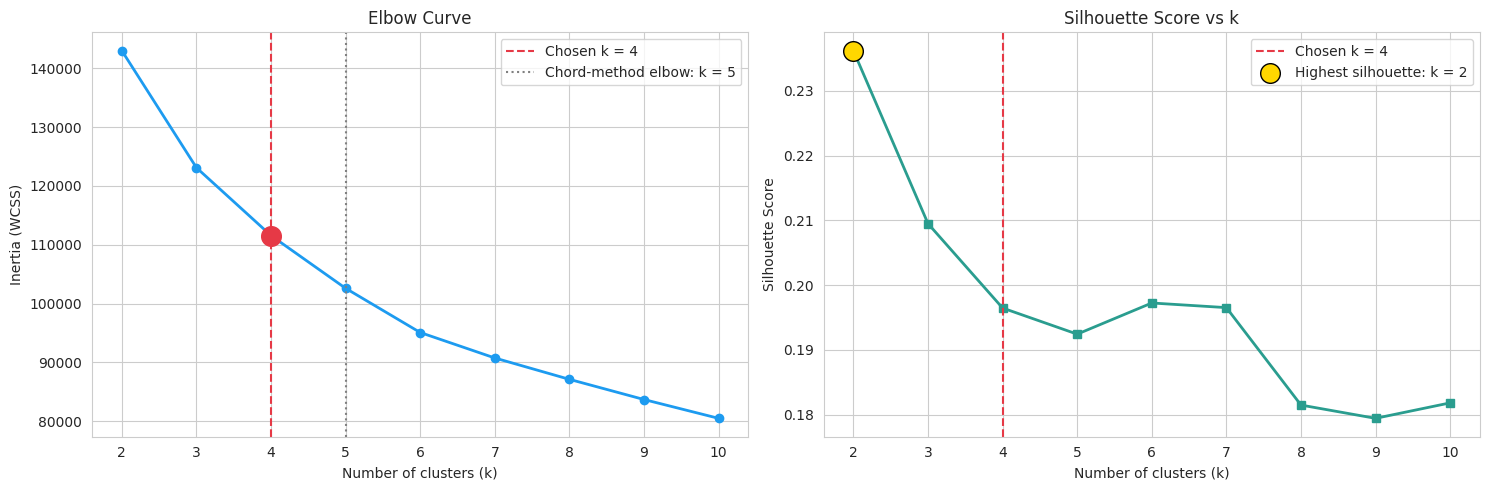

In [22]:
k_optimal = 4      # chosen after looking at both plots (justification below)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_values, inertias, marker='o', color='#1d9bf0', lw=2)
axes[0].axvline(k_optimal, color='#e63946', ls='--', label=f'Chosen k = {k_optimal}')
axes[0].axvline(k_elbow, color='grey', ls=':', label=f'Chord-method elbow: k = {k_elbow}')
axes[0].scatter([k_optimal], [inertias[k_values.index(k_optimal)]], s=200, color='#e63946', zorder=5)
axes[0].set_xlabel('Number of clusters (k)'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Curve'); axes[0].legend()

axes[1].plot(k_values, sil_scores, marker='s', color='#2a9d8f', lw=2)
axes[1].axvline(k_optimal, color='#e63946', ls='--', label=f'Chosen k = {k_optimal}')
axes[1].scatter([k_best_sil], [max(sil_scores)], s=200, color='gold', edgecolor='k', zorder=5, label=f'Highest silhouette: k = {k_best_sil}')
axes[1].set_xlabel('Number of clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k'); axes[1].legend()

plt.tight_layout()
save_fig('11_kmeans_elbow_silhouette')
plt.show()

**Choice of k = 4 — justification:** The silhouette score is highest at **k = 2** (≈ 0.24), but two segments (basically "spenders" vs "non-spenders") is too coarse
to design different card offers. The elbow in this data is *soft*: the curve keeps bending through k = 4–5 (the numerical chord method points to k = 5), and the silhouette stays almost flat
(≈ 0.19–0.20) for k = 4 to 7. I therefore choose **k = 4**: it is inside the elbow region, its silhouette (0.1965) is as good as k = 5, 6 or 7, it gives a manageable number of
actionable segments, and it matches the 4-cluster cut of the dendrogram so that K-Means and Hierarchical results can be compared fairly.

## 3.2 Train Final K-Means Model

In [23]:
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=42)
kmeans_final.fit(X)

fe['KMeans_Cluster'] = kmeans_final.labels_       # labels go on the ORIGINAL unscaled DataFrame
print(fe['KMeans_Cluster'].value_counts().sort_index())
print('Final inertia:', round(kmeans_final.inertia_, 1))

KMeans_Cluster
0    2602
1    2322
2    2311
3    1715
Name: count, dtype: int64
Final inertia: 111552.0


## 3.3 Visualise K-Means Clusters
All scatter plots below use **log1p-scaled axes** so that the heavily skewed money columns are readable.

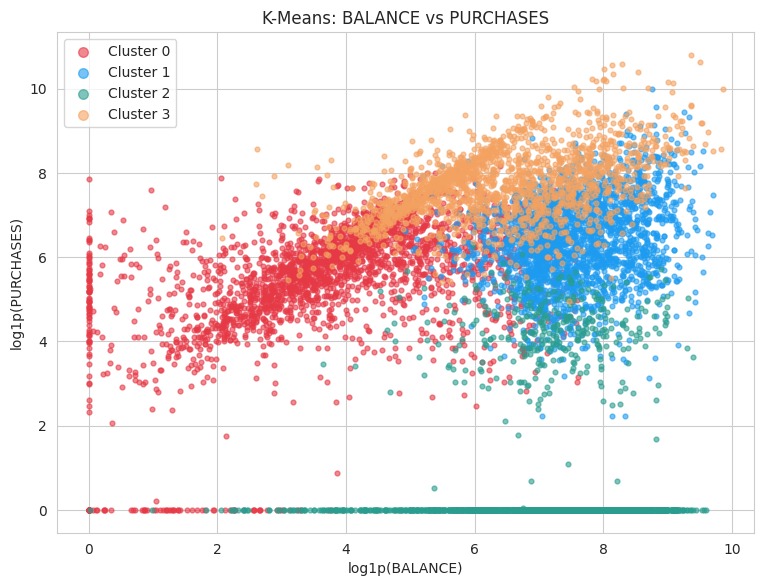

In [24]:
def scatter2d(labels, xcol, ycol, title, fname, names=None):
    labels = np.asarray(labels)
    plt.figure(figsize=(9, 6.5))
    for lab in sorted(np.unique(labels)):
        m = labels == lab
        if lab == -1:
            plt.scatter(np.log1p(fe.loc[m, xcol]), np.log1p(fe.loc[m, ycol]), c='lightgrey', s=14, alpha=0.6, label='Noise (-1)')
        else:
            nm = names[lab] if names else f'Cluster {lab}'
            plt.scatter(np.log1p(fe.loc[m, xcol]), np.log1p(fe.loc[m, ycol]), color=PALETTE[lab % len(PALETTE)], s=12, alpha=0.6, label=nm)
    plt.xlabel(f'log1p({xcol})'); plt.ylabel(f'log1p({ycol})'); plt.title(title)
    plt.legend(markerscale=2)
    save_fig(fname)
    plt.show()

def scatter3d(labels, title, fname, names=None, elev=22, azim=-58):
    labels = np.asarray(labels)
    xs, ys, zs = (np.log1p(fe[c]).values for c in ['BALANCE', 'PURCHASES', 'CASH_ADVANCE'])
    fig = plt.figure(figsize=(11, 8.5))
    ax = fig.add_subplot(111, projection='3d')
    for lab in sorted(np.unique(labels)):
        m = labels == lab
        if lab == -1:
            ax.scatter(xs[m], ys[m], zs[m], c='lightgrey', s=12, alpha=0.5, label='Noise (-1)')
        else:
            nm = names[lab] if names else f'Cluster {lab}'
            ax.scatter(xs[m], ys[m], zs[m], color=PALETTE[lab % len(PALETTE)], s=9, alpha=0.65, label=nm)
    ax.set_xlabel('log1p(BALANCE)', labelpad=10); ax.set_ylabel('log1p(PURCHASES)', labelpad=10)
    ax.text2D(0.93, 0.5, 'log1p(CASH_ADVANCE)', transform=ax.transAxes, rotation=90, va='center')   # z-label (set_zlabel gets clipped)
    ax.set_title(title, pad=15)
    ax.view_init(elev=elev, azim=azim)
    ax.legend(markerscale=2.5, loc='upper left')
    save_fig(fname)
    plt.show()

scatter2d(fe['KMeans_Cluster'], 'BALANCE', 'PURCHASES', 'K-Means: BALANCE vs PURCHASES', '12_kmeans_balance_purchases')

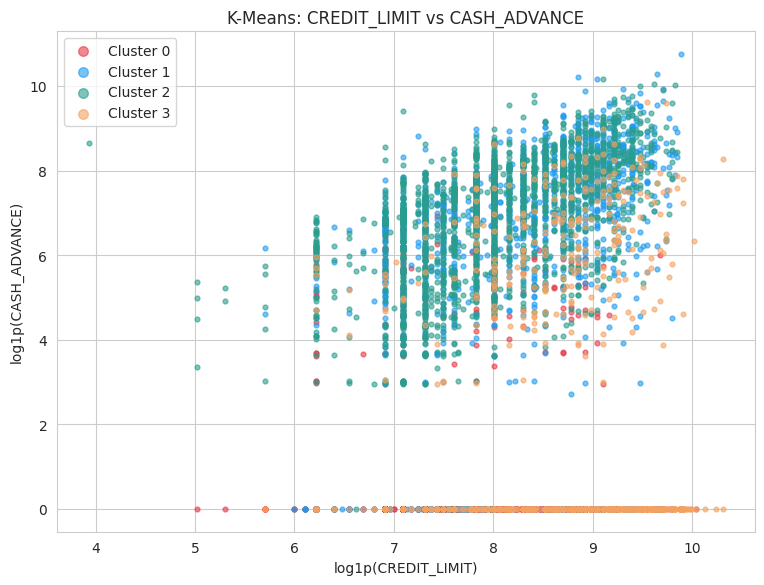

In [25]:
scatter2d(fe['KMeans_Cluster'], 'CREDIT_LIMIT', 'CASH_ADVANCE', 'K-Means: CREDIT_LIMIT vs CASH_ADVANCE', '13_kmeans_limit_cashadvance')

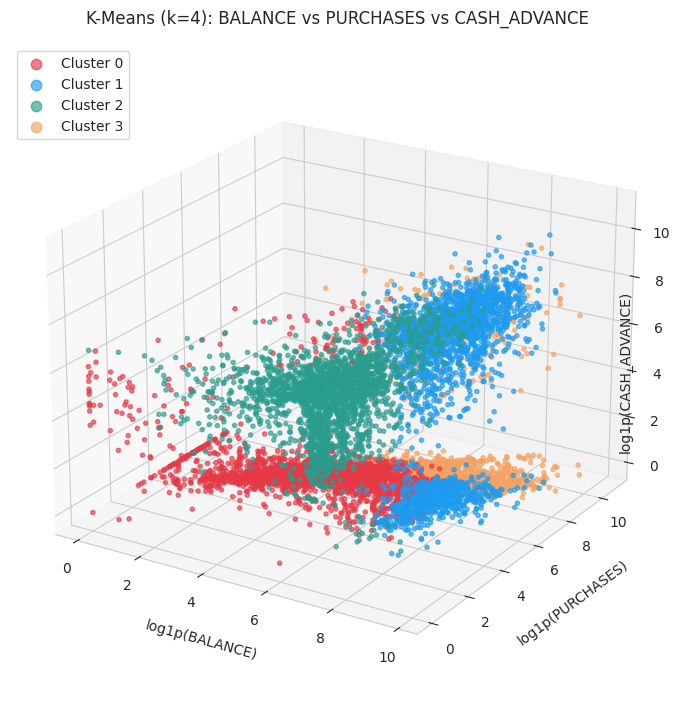

In [26]:
# KEY VISUAL: 3D scatter  BALANCE vs PURCHASES vs CASH_ADVANCE
scatter3d(fe['KMeans_Cluster'], 'K-Means (k=4): BALANCE vs PURCHASES vs CASH_ADVANCE', '14_kmeans_3d')

In [27]:
# interactive plotly version of the same 3D plot (saved as an HTML file - open it in a browser and rotate it)
plot_df = pd.DataFrame({'log1p(BALANCE)': np.log1p(fe['BALANCE']), 'log1p(PURCHASES)': np.log1p(fe['PURCHASES']),
                        'log1p(CASH_ADVANCE)': np.log1p(fe['CASH_ADVANCE']),
                        'Cluster': 'Cluster ' + fe['KMeans_Cluster'].astype(str)})
fig3d = px.scatter_3d(plot_df, x='log1p(BALANCE)', y='log1p(PURCHASES)', z='log1p(CASH_ADVANCE)', color='Cluster',
                      opacity=0.6, title='K-Means clusters (interactive 3D)', color_discrete_sequence=PALETTE)
fig3d.update_traces(marker=dict(size=2.5))
fig3d.write_html('images/kmeans_3d_interactive.html', include_plotlyjs='cdn')
print('Interactive plot saved to images/kmeans_3d_interactive.html')

Interactive plot saved to images/kmeans_3d_interactive.html


## 3.4 Profile the K-Means Clusters

In [28]:
profile_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'TENURE']
extra_cols   = ['PURCHASES_FREQUENCY', 'PRC_FULL_PAYMENT', 'Limit_Usage']      # help in naming the personas

def name_persona(r):
    # simple business rules applied to a cluster's mean profile (ORIGINAL unscaled values)
    if r['PURCHASES'] < 50 and r['CASH_ADVANCE'] < 500 and r['BALANCE'] < 100:
        return 'Dormant Cardholders'
    if r['TENURE'] < 9:
        return 'New-to-Card'
    if r['PURCHASES'] > 2000 and r['PURCHASES_FREQUENCY'] > 0.8:
        return 'Premium Transactors'
    if r['CASH_ADVANCE'] > 1000 and r['PURCHASES_FREQUENCY'] < 0.3:
        return 'Cash-Advance Reliant'
    if r['BALANCE'] > 2000 and r['Limit_Usage'] > 0.5:
        return 'Active Revolvers'
    if r['BALANCE'] < 500 and r['Limit_Usage'] < 0.15:
        return 'Low-Balance Light Spenders'
    return 'Mainstream Mixed-Use'

def profile_clusters(label_col, exclude_noise=True):
    d = fe[fe[label_col] != -1] if exclude_noise else fe
    prof = d.groupby(label_col)[profile_cols + extra_cols].mean()
    prof['Customers'] = d.groupby(label_col).size()
    prof['% of customers'] = (prof['Customers'] / len(fe) * 100).round(1)
    prof['Persona'] = prof.apply(name_persona, axis=1)
    return prof

km_profile = profile_clusters('KMeans_Cluster')
kmeans_persona_map = km_profile['Persona'].to_dict()
assert len(set(kmeans_persona_map.values())) == len(kmeans_persona_map), 'personas must be unique'

fe['KMeans_Persona'] = fe['KMeans_Cluster'].map(kmeans_persona_map)
display(km_profile.sort_values('CREDIT_LIMIT', ascending=False).round(2))

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,PURCHASES_FREQUENCY,PRC_FULL_PAYMENT,Limit_Usage,Customers,% of customers,Persona
KMeans_Cluster,,,,,,,,,,,,
3,1362.67,3232.49,172.66,6763.32,3153.40,11.87,0.90,0.31,0.21,1715,19.2,Premium Transactors
1,2666.76,963.89,1558.35,4425.19,1909.63,11.59,0.60,0.02,0.68,2322,25.9,Active Revolvers
2,2205.10,12.88,2063.42,4074.24,1679.31,11.35,0.02,0.03,0.59,2311,25.8,Cash-Advance Reliant
0,144.84,448.52,29.87,3433.46,687.37,11.37,0.54,0.28,0.06,2602,29.1,Low-Balance Light Spenders


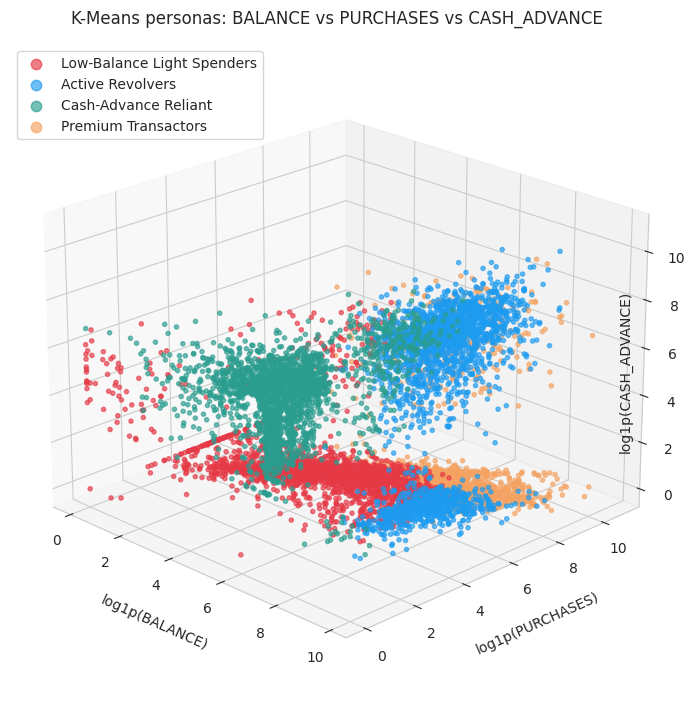

In [29]:
# the key 3D visual again, now with persona names in the legend
scatter3d(fe['KMeans_Cluster'], 'K-Means personas: BALANCE vs PURCHASES vs CASH_ADVANCE', '14b_kmeans_3d_personas', names=kmeans_persona_map, azim=-45)

### K-Means personas — justification (from the profile table above)

| Persona | Evidence in the cluster profile | Meaning for the bank |
|---|---|---|
| **Premium Transactors** | Highest `CREDIT_LIMIT` (~₹6,800) and by far the highest `PURCHASES` (~3,200); purchases happen almost every month (frequency ≈ 0.9); one-off and instalment spending are both high; pays in full more often (≈ 31%); low cash advance | Core spenders, generate interchange income, low risk — candidates for premium cards and higher limits |
| **Active Revolvers** | Highest `BALANCE` (~2,700) with ~68% of limit used; pays almost never in full (≈ 2%); moderate purchases *and* heavy cash advance (~1,550) | Carry debt month to month — the main source of **interest income**; best for balance-transfer / EMI offers |
| **Cash-Advance Reliant** | Almost **zero purchases** (~13, frequency ≈ 0.02) but a very high `CASH_ADVANCE` (~2,060) and ~59% limit usage; rarely pays in full | Use the card like a loan — highest credit-risk group, needs monitoring and a cheaper alternative product |
| **Low-Balance Light Spenders** | Very low `BALANCE` (~145, only ~6% of limit used), modest purchases (~450), almost no cash advance, ≈ 28% pay in full | Safe but under-used — opportunity to grow wallet share with rewards and instalment offers |

---
# 🌳 Step 4: Agglomerative Hierarchical Clustering
## 4.1 Dendrogram Analysis

In [30]:
Z = linkage(cc_scaled, method='ward')

# distance range that gives 3, 4 and 5 clusters (cut must lie between consecutive merge heights)
h = Z[:, 2]
for k in [3, 4, 5]:
    low, high = h[-k], h[-(k - 1)]
    print(f'{k} clusters  ->  cut the dendrogram at a distance between {low:.1f} and {high:.1f}')

n_chosen = 4
cut_distance = (h[-n_chosen] + h[-(n_chosen - 1)]) / 2
print(f'\nChosen: {n_chosen} clusters, cut line at distance = {cut_distance:.1f}')
print('Check with fcluster ->', len(np.unique(fcluster(Z, t=cut_distance, criterion="distance"))), 'clusters')

3 clusters  ->  cut the dendrogram at a distance between 138.4 and 191.2
4 clusters  ->  cut the dendrogram at a distance between 122.6 and 138.4
5 clusters  ->  cut the dendrogram at a distance between 109.6 and 122.6

Chosen: 4 clusters, cut line at distance = 130.5
Check with fcluster -> 4 clusters


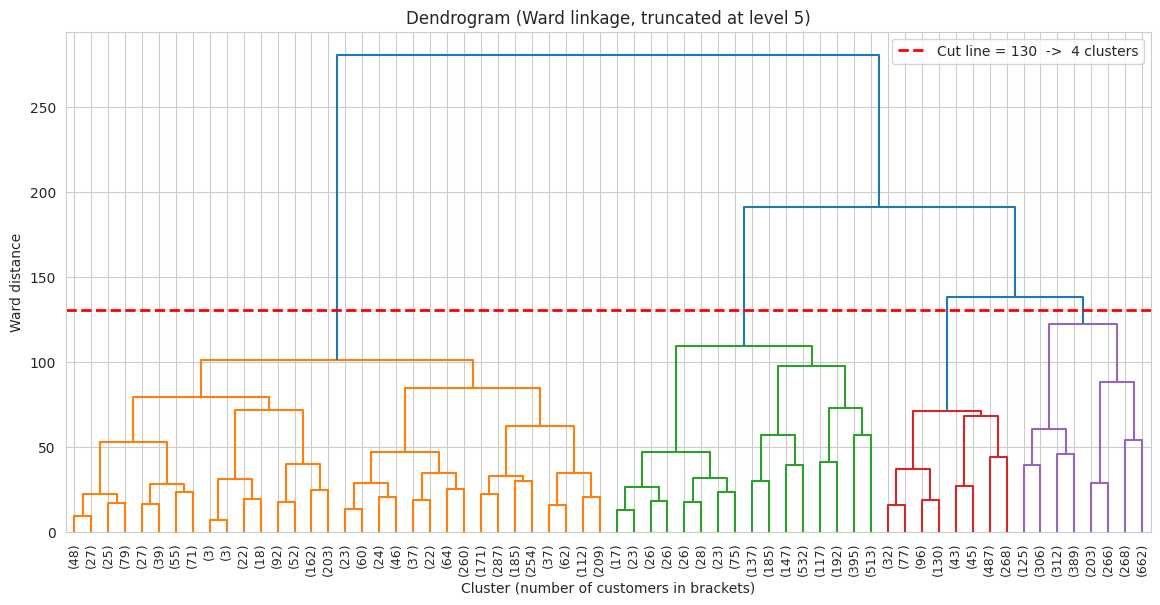

In [31]:
plt.figure(figsize=(14, 6.5))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=9, color_threshold=cut_distance)
plt.axhline(cut_distance, color='red', ls='--', lw=2, label=f'Cut line = {cut_distance:.0f}  ->  {n_chosen} clusters')
plt.title('Dendrogram (Ward linkage, truncated at level 5)')
plt.xlabel('Cluster (number of customers in brackets)'); plt.ylabel('Ward distance')
plt.legend(loc='upper right')
save_fig('15_dendrogram')
plt.show()

**Chosen cut:** Cutting at a Ward distance of about **130** gives **4 clusters** (3 clusters would need a cut between ~138 and ~191, and 5 clusters between ~110 and ~123).
The gap between consecutive merge heights is not dramatic at this level (the data has no sharp cluster boundary), so I choose 4 mainly because it gives actionable segments and lets me compare the hierarchical result fairly with K-Means (k = 4).

## 4.2 Train Agglomerative Model — Compare Linkages

In [32]:
agg_rows, agg_labels = [], {}
for link in ['ward', 'complete', 'average']:
    lab = AgglomerativeClustering(n_clusters=n_chosen, linkage=link).fit_predict(X)
    agg_labels[link] = lab
    sizes = np.bincount(lab)
    agg_rows.append([link, round(silhouette_score(X, lab), 4), sizes.tolist(), round(sizes.min() / len(X) * 100, 2)])

agg_cmp = pd.DataFrame(agg_rows, columns=['Linkage', 'Silhouette', 'Cluster sizes', 'Smallest cluster %'])
display(agg_cmp)

# rule: best silhouette among linkages whose smallest cluster is at least 5% of customers
# (a silhouette of a clustering with 1-customer clusters is not useful for the business)
valid = agg_cmp[agg_cmp['Smallest cluster %'] >= 5]
best_link = valid.loc[valid['Silhouette'].idxmax(), 'Linkage']
print('Best linkage:', best_link)

fe['Agg_Cluster'] = agg_labels[best_link]
print(fe['Agg_Cluster'].value_counts().sort_index())

,Linkage,Silhouette,Cluster sizes,Smallest cluster %
0,ward,0.1560,"[2531, 2779, 2462, 1178]",13.16
1,complete,0.0818,"[5793, 3068, 61, 28]",0.31
2,average,0.3554,"[8941, 2, 1, 6]",0.01


Best linkage: ward
Agg_Cluster
0    2531
1    2779
2    2462
3    1178
Name: count, dtype: int64


**Observation on linkages:** **Ward** produces four compact, almost equal-sized clusters (the behaviour described in the exam note — similar to K-Means).
**Complete** and especially **Average** linkage produce very **unequal** clusters: one giant cluster with most customers and tiny clusters of a few customers.
Average linkage shows the *highest* silhouette number only because it isolates a handful of extreme customers — that is a statistical artefact, not a useful segmentation.
So I select **Ward** as the best linkage for business use.

## 4.3 Visualise & Profile Hierarchical Clusters

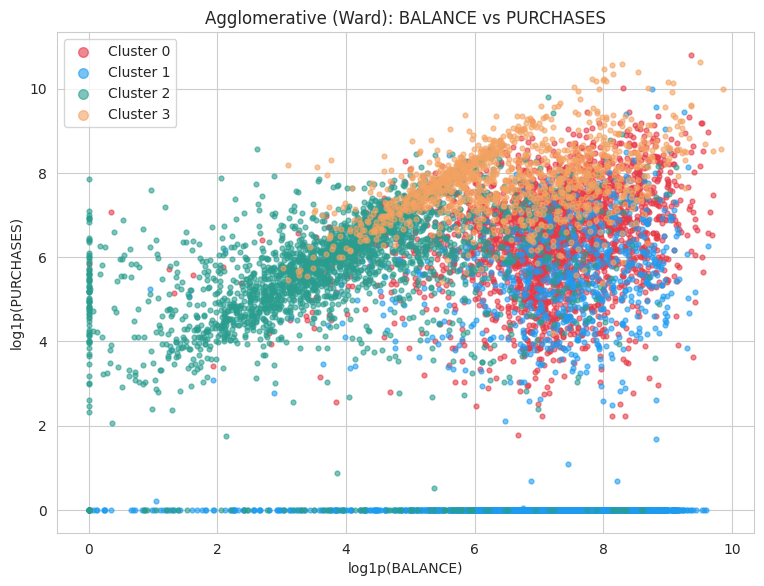

In [33]:
scatter2d(fe['Agg_Cluster'], 'BALANCE', 'PURCHASES', 'Agglomerative (Ward): BALANCE vs PURCHASES', '16_agg_balance_purchases')

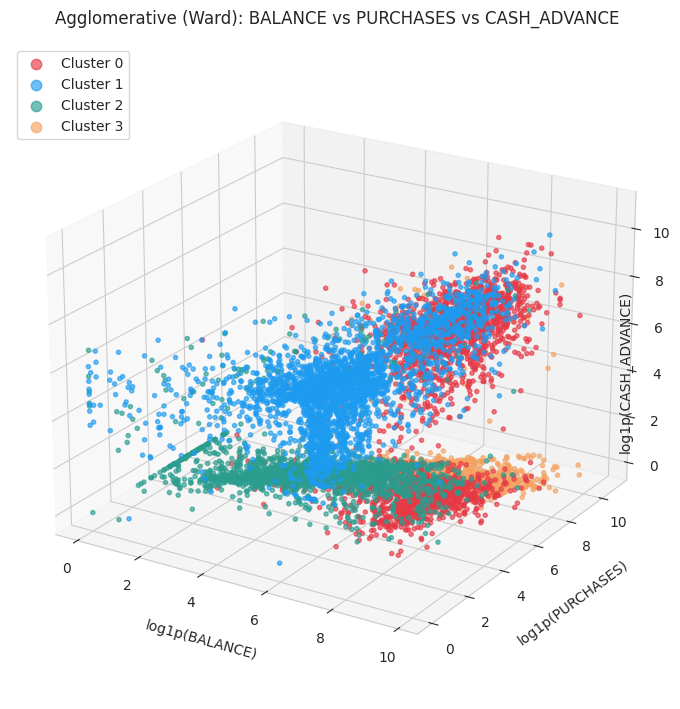

In [34]:
scatter3d(fe['Agg_Cluster'], 'Agglomerative (Ward): BALANCE vs PURCHASES vs CASH_ADVANCE', '17_agg_3d')

In [35]:
agg_profile = profile_clusters('Agg_Cluster')
agg_persona_map = agg_profile['Persona'].to_dict()
fe['Agg_Persona'] = fe['Agg_Cluster'].map(agg_persona_map)
display(agg_profile.sort_values('CREDIT_LIMIT', ascending=False).round(2))

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,PURCHASES_FREQUENCY,PRC_FULL_PAYMENT,Limit_Usage,Customers,% of customers,Persona
Agg_Cluster,,,,,,,,,,,,
3,1501.74,3519.56,40.43,6883.20,3228.21,11.96,0.92,0.33,0.23,1178,13.2,Premium Transactors
0,2123.94,1153.32,1017.45,4407.67,1904.67,11.92,0.64,0.04,0.57,2531,28.3,Active Revolvers
1,2281.04,164.82,2143.21,4224.90,1791.51,11.17,0.09,0.04,0.58,2779,31.1,Cash-Advance Reliant
2,210.51,591.21,73.98,3744.36,775.58,11.28,0.59,0.31,0.07,2462,27.5,Low-Balance Light Spenders


In [36]:
# how well do Hierarchical and K-Means agree?
print('Adjusted Rand Index (K-Means vs Agglomerative):', round(adjusted_rand_score(fe['KMeans_Cluster'], fe['Agg_Cluster']), 3))
print()
display(pd.crosstab(fe['KMeans_Persona'], fe['Agg_Persona'], rownames=['K-Means'], colnames=['Agglomerative']))

Adjusted Rand Index (K-Means vs Agglomerative): 0.543



Agglomerative,Active Revolvers,Cash-Advance Reliant,Low-Balance Light Spenders,Premium Transactors
K-Means,,,,
Active Revolvers,1729,496,60,37
Cash-Advance Reliant,84,2157,70,0
Low-Balance Light Spenders,331,122,2116,33
Premium Transactors,387,4,216,1108


**Comparison with K-Means:** The Hierarchical (Ward) clusters recover the **same four personas** as K-Means, but they do not match exactly (Adjusted Rand Index ≈ 0.54).
They agree best on **Cash-Advance Reliant** (2,157 customers in both) and **Low-Balance Light Spenders** (2,116). The main disagreement is the **Premium Transactors** group:
K-Means has 1,715 of them but Ward only 1,178 — about 600 moderate-to-high spenders that K-Means calls Premium are placed by Ward in *Active Revolvers* (387) or *Light Spenders* (216).
A second disagreement is the Active-Revolver / Cash-Advance boundary (496 K-Means revolvers become Ward cash-advance users). The data is a continuous spectrum with no sharp gaps there,
so borderline customers can fall on either side depending on the method.

---
# 🔴 Step 5: DBSCAN Clustering
## 5.1 Tune Epsilon (ε) using the k-NN Distance Plot

Optimal eps from the knee of the curve: 2.41


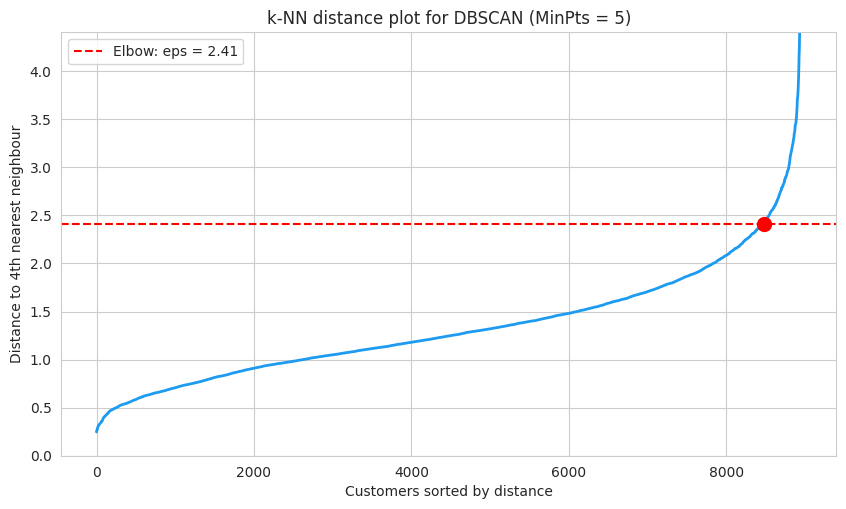

In [37]:
min_pts = 5
nn = NearestNeighbors(n_neighbors=min_pts).fit(X)
distances, _ = nn.kneighbors(X)
kdist = np.sort(distances[:, -1])           # distance to the (MinPts-1)-th other neighbour (first column is the point itself)

# knee = point furthest from the straight line joining first and last point of the sorted curve
pts = np.column_stack([np.arange(len(kdist)), kdist])
v = (pts[-1] - pts[0]) / np.linalg.norm(pts[-1] - pts[0])
w = pts - pts[0]
knee_idx = int(np.abs(w[:, 0] * v[1] - w[:, 1] * v[0]).argmax())
optimal_eps = round(float(kdist[knee_idx]), 2)
print('Optimal eps from the knee of the curve:', optimal_eps)

plt.figure(figsize=(10, 5.5))
plt.plot(kdist, color='#1d9bf0', lw=2)
plt.axhline(optimal_eps, color='red', ls='--', label=f'Elbow: eps = {optimal_eps}')
plt.scatter([knee_idx], [kdist[knee_idx]], color='red', s=100, zorder=5)
plt.xlabel('Customers sorted by distance'); plt.ylabel(f'Distance to {min_pts - 1}th nearest neighbour')
plt.title('k-NN distance plot for DBSCAN (MinPts = 5)')
plt.ylim(0, np.percentile(kdist, 99.8)); plt.legend()
save_fig('18_knn_distance_plot')
plt.show()

**Choice of ε:** The curve stays flat (dense region) for most customers and then bends sharply upward — the bend is at **ε ≈ 2.4**.
Points to the left of the bend have close neighbours (cluster points); points to the right are isolated (noise candidates).

## 5.2 Train DBSCAN Model (ε from the elbow, min_samples = 5)

In [38]:
db_first = DBSCAN(eps=optimal_eps, min_samples=5, metric='euclidean').fit(X)
lab = db_first.labels_
n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
n_noise = int((lab == -1).sum())

fe['DBSCAN_Cluster'] = lab
print(f'(a) Clusters found (excluding noise) : {n_clusters}')
print(f'(b) Noise points                     : {n_noise}')
print(f'(c) % of customers classified noise  : {n_noise / len(X) * 100:.2f}%')

(a) Clusters found (excluding noise) : 1
(b) Noise points                     : 236
(c) % of customers classified noise  : 2.64%


**Observation:** At the elbow ε, DBSCAN finds **only one big dense cluster** and flags a small number of customers as noise.
In 21 dimensions the data has no clear low-density gaps between behavioural groups, so DBSCAN cannot split the main crowd into segments — which is why the grid search in 5.3 is needed.

## 5.3 Tune DBSCAN Hyper-parameters (grid search)
The grid asked in the exam is `eps = [0.3, 0.5, 0.7, 1.0, 1.5]`. Because the k-NN elbow (≈ 2.4) lies **outside** that range,
I also added `eps = 2.0` and `2.5` so that the sensible region is covered.

In [39]:
eps_grid = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5]
ms_grid  = [3, 5, 8, 10]

grid_rows = []
for e in eps_grid:
    for m in ms_grid:
        l = DBSCAN(eps=e, min_samples=m).fit_predict(X)
        mask = l != -1
        ncl = len(set(l[mask]))
        sil = silhouette_score(X[mask], l[mask]) if ncl >= 2 else np.nan      # silhouette only on non-noise points
        grid_rows.append([e, m, ncl, int((~mask).sum()), round((~mask).mean() * 100, 2), sil])

grid = pd.DataFrame(grid_rows, columns=['eps', 'min_samples', 'n_clusters', 'n_noise', 'noise_%', 'silhouette'])
display(grid.round(3))

,eps,min_samples,n_clusters,n_noise,noise_%,silhouette
0,0.3,3,22,8821,98.56,0.464
1,0.3,5,7,8901,99.45,0.384
2,0.3,8,1,8939,99.88,NaN
3,0.3,10,0,8950,100.00,NaN
4,0.5,3,87,8182,91.42,0.153
5,0.5,5,25,8530,95.31,0.210
6,0.5,8,5,8729,97.53,0.283
7,0.5,10,1,8788,98.19,NaN
8,0.7,3,152,6946,77.61,-0.074
9,0.7,5,39,7534,84.18,-0.040


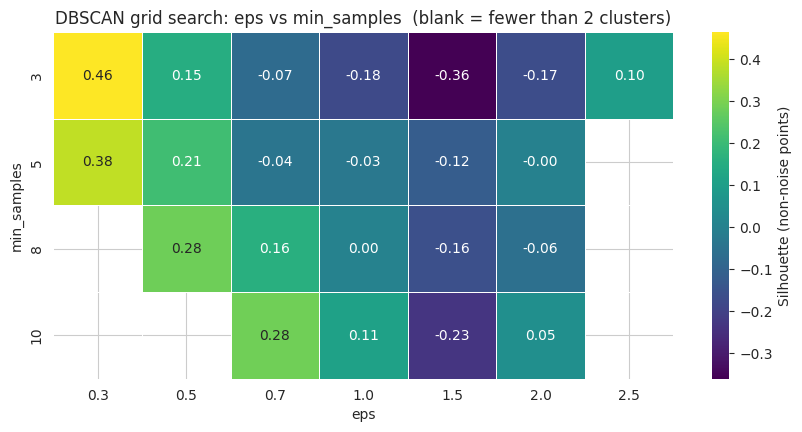

In [40]:
pivot = grid.pivot(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(10, 4.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis', linewidths=.5, cbar_kws={'label': 'Silhouette (non-noise points)'})
plt.title('DBSCAN grid search: eps vs min_samples  (blank = fewer than 2 clusters)')
save_fig('19_dbscan_grid_heatmap')
plt.show()

In [41]:
# Selection rule: a useful DBSCAN model must find at least 2 clusters and must not throw away more than 15% of customers.
# (e.g. eps=0.3, min_samples=3 has the highest raw silhouette, but it labels ~99% of customers as noise -> useless.)
valid = grid[(grid['n_clusters'] >= 2) & (grid['noise_%'] <= 15)]
best_row = valid.loc[valid['silhouette'].idxmax()]
best_eps, best_ms = float(best_row['eps']), int(best_row['min_samples'])
print('Best combination ->', 'eps =', best_eps, ', min_samples =', best_ms)
print(best_row.round(3).to_dict())

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_ms, metric='euclidean').fit(X)
fe['DBSCAN_Cluster'] = dbscan_final.labels_
print('\nCluster sizes (-1 = noise):')
print(fe['DBSCAN_Cluster'].value_counts().sort_index())

Best combination -> eps = 2.5 , min_samples = 3
{'eps': 2.5, 'min_samples': 3.0, 'n_clusters': 5.0, 'n_noise': 147.0, 'noise_%': 1.64, 'silhouette': 0.097}



Cluster sizes (-1 = noise):
DBSCAN_Cluster
-1     147
 0    8791
 1       3
 2       3
 3       3
 4       3
Name: count, dtype: int64


## 5.4 Visualise & Profile DBSCAN Clusters

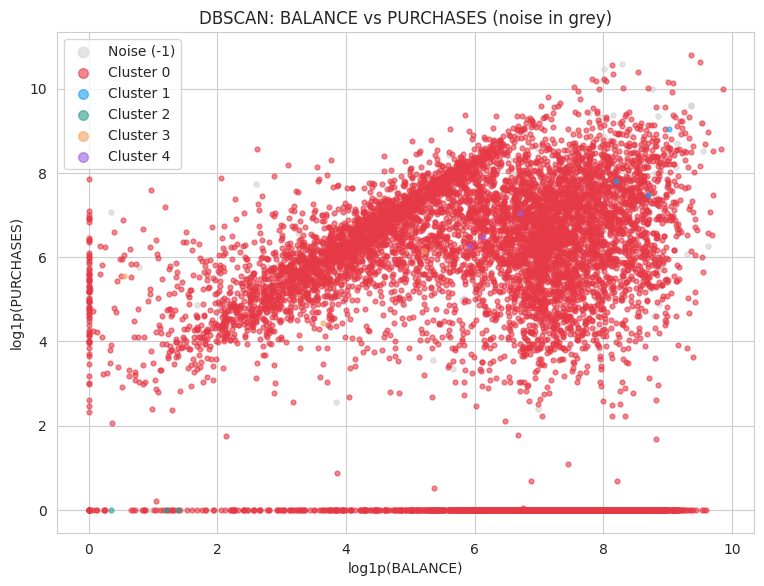

In [42]:
scatter2d(fe['DBSCAN_Cluster'], 'BALANCE', 'PURCHASES', 'DBSCAN: BALANCE vs PURCHASES (noise in grey)', '20_dbscan_balance_purchases')

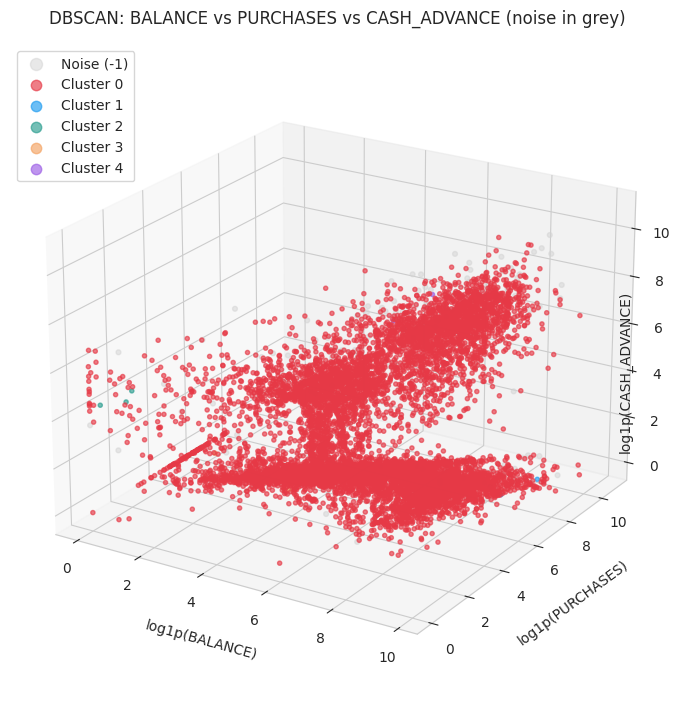

In [43]:
scatter3d(fe['DBSCAN_Cluster'], 'DBSCAN: BALANCE vs PURCHASES vs CASH_ADVANCE (noise in grey)', '21_dbscan_3d')

In [44]:
db_profile = profile_clusters('DBSCAN_Cluster', exclude_noise=True)
dbscan_persona_map = db_profile['Persona'].to_dict()
display(db_profile.round(2))

# what do the noise customers look like compared with everybody else?
noise = fe[fe['DBSCAN_Cluster'] == -1]
compare = pd.DataFrame({'Noise customers (mean)': noise[profile_cols + extra_cols].mean(),
                        'All customers (mean)': fe[profile_cols + extra_cols].mean()}).round(2)
print(f'Noise customers: {len(noise)} ({len(noise) / len(fe) * 100:.1f}%)')
display(compare)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,PURCHASES_FREQUENCY,PRC_FULL_PAYMENT,Limit_Usage,Customers,% of customers,Persona
DBSCAN_Cluster,,,,,,,,,,,,
0,1548.52,974.44,938.19,4474.32,1675.95,11.55,0.49,0.15,0.39,8791,98.2,Mainstream Mixed-Use
1,5952.47,4204.87,0.00,6833.33,3694.43,12.00,1.00,0.00,0.85,3,0.0,Premium Transactors
2,1.91,0.00,175.68,1400.00,897.71,8.00,0.00,0.00,0.00,3,0.0,Dormant Cardholders
3,73.89,268.12,0.00,1500.00,0.00,7.33,0.80,0.00,0.05,3,0.0,New-to-Card
4,549.82,776.53,1700.64,1333.33,2151.69,7.00,0.86,0.22,0.41,3,0.0,New-to-Card


Noise customers: 147 (1.6%)


,Noise customers (mean),All customers (mean)
BALANCE,2511.88,1564.47
PURCHASES,2698.30,1003.20
CASH_ADVANCE,3453.60,978.87
CREDIT_LIMIT,5829.05,4494.28
PAYMENTS,5157.43,1733.14
TENURE,9.93,11.52
PURCHASES_FREQUENCY,0.61,0.49
PRC_FULL_PAYMENT,0.20,0.15
Limit_Usage,0.55,0.39


**What did DBSCAN call "noise"?** The noise customers are the **extreme accounts**: their average cash advance (≈ 3,450 vs 980), payments (≈ 5,160 vs 1,730) and purchases (≈ 2,700 vs 1,000)
are roughly **3× the portfolio average**, and they mix heavy spending *with* heavy cash advance — so they fit no ordinary cluster.
For the **credit-risk team** these accounts need manual review (very high cash-advance + large balances = potential stress or misuse); for the **marketing team** the high-spend ones
are VIP candidates for personal Relationship-Manager outreach rather than automated campaigns. DBSCAN's remaining non-noise clusters other than the one big mainstream group are tiny pockets of just 3 customers each (new-to-card, dormant or instalment-heavy accounts),
so DBSCAN is more useful here as an **outlier detector** than as a segmentation tool.

---
# 📊 Step 6: Algorithm Comparison & Business Interpretation
## 6.1 Internal Metrics Comparison Table

In [45]:
def evaluate(X_, labels):
    labels = np.asarray(labels)
    mask = labels != -1                      # noise points are ignored for the metrics
    return (silhouette_score(X_[mask], labels[mask]),
            davies_bouldin_score(X_[mask], labels[mask]),
            calinski_harabasz_score(X_[mask], labels[mask]))

models = {
    'K-Means':                       (f'k={k_optimal}, init=k-means++, n_init=20, random_state=42', fe['KMeans_Cluster']),
    'Agglomerative':                 (f'n_clusters={n_chosen}, linkage={best_link}', fe['Agg_Cluster']),
    'DBSCAN':                        (f'eps={best_eps}, min_samples={best_ms}', fe['DBSCAN_Cluster']),
}

rows = []
for name, (params, labels) in models.items():
    labels = np.asarray(labels)
    s, d, c = evaluate(X, labels)
    rows.append([name, params, len(set(labels)) - (1 if -1 in labels else 0), round(s, 4), round(d, 4), round(c, 1),
                 round((labels == -1).mean() * 100, 2)])

comparison = pd.DataFrame(rows, columns=['Algorithm', 'Final hyperparameters', 'Clusters', 'Silhouette (higher better)',
                                         'Davies-Bouldin (lower better)', 'Calinski-Harabasz (higher better)', '% Noise'])

# rank (1 = best) on each metric, then average
comparison['rank_sil'] = comparison['Silhouette (higher better)'].rank(ascending=False)
comparison['rank_db']  = comparison['Davies-Bouldin (lower better)'].rank(ascending=True)
comparison['rank_ch']  = comparison['Calinski-Harabasz (higher better)'].rank(ascending=False)
comparison['Average rank'] = comparison[['rank_sil', 'rank_db', 'rank_ch']].mean(axis=1).round(2)
# tie-break equal average ranks with the silhouette score
comparison = comparison.sort_values(['Average rank', 'Silhouette (higher better)'], ascending=[True, False]).reset_index(drop=True)
comparison['Final rank'] = comparison.index + 1
display(comparison.drop(columns=['rank_sil', 'rank_db', 'rank_ch']))

,Algorithm,Final hyperparameters,Clusters,Silhouette (higher better),Davies-Bouldin (lower better),Calinski-Harabasz (higher better),% Noise,Average rank,Final rank
0,K-Means,"k=4, init=k-means++, n_init=20, random_state=42",4,0.1964,1.7007,2042.3,0.00,1.33,1
1,Agglomerative,"n_clusters=4, linkage=ward",4,0.1560,1.9096,1656.5,0.00,2.33,2
2,DBSCAN,"eps=2.5, min_samples=3",5,0.0970,0.8707,7.7,1.64,2.33,3


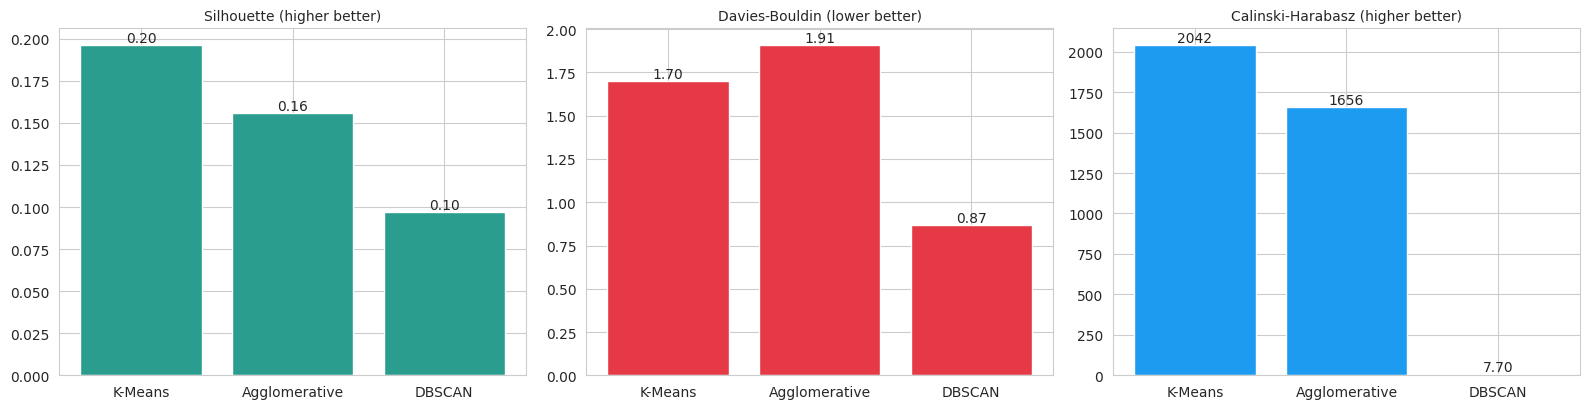

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, col, color in zip(axes, ['Silhouette (higher better)', 'Davies-Bouldin (lower better)', 'Calinski-Harabasz (higher better)'],
                          ['#2a9d8f', '#e63946', '#1d9bf0']):
    ax.bar(comparison['Algorithm'], comparison[col], color=color)
    ax.set_title(col, fontsize=10)
    for i, v in enumerate(comparison[col]):
        ax.text(i, v, f'{v:.2f}' if v < 100 else f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout()
save_fig('22_metrics_comparison')
plt.show()

**Ranking:** 1️⃣ **K-Means**, 2️⃣ **Agglomerative (Ward)**, 3️⃣ **DBSCAN**.
K-Means has the best **Silhouette (0.196)** and **Calinski-Harabasz (2,042)** and the best average rank; Ward is behind it on both (0.156 and 1,657).
DBSCAN shows the lowest (best-looking) **Davies-Bouldin (0.87)**, but this is an **artefact**: its clusters are one giant group of 8,791 customers plus four pockets of 3 customers each — tiny
clusters are trivially "compact" — and its Calinski-Harabasz is only 7.7. DBSCAN's metrics are also computed only on non-noise points, so they are not directly comparable.
Average ranks of Ward and DBSCAN tie (2.33), so I break the tie with the silhouette score. The result agrees with business intuition: K-Means and Ward give four balanced, interpretable segments, while DBSCAN is better used for outlier detection.

## 6.2 Cluster Stability Check for K-Means

In [47]:
stab_rows = []
for seed in [0, 7, 21, 42, 99]:
    km = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=seed).fit(X)
    stab_rows.append([seed, round(silhouette_score(X, km.labels_), 4),
                      round(adjusted_rand_score(kmeans_final.labels_, km.labels_), 4)])

stab = pd.DataFrame(stab_rows, columns=['random_state', 'Silhouette', 'ARI vs final model'])
display(stab)
print(f'Silhouette: mean = {stab["Silhouette"].mean():.4f}  +/-  std = {stab["Silhouette"].std():.5f}')

,random_state,Silhouette,ARI vs final model
0,0,0.1967,0.9644
1,7,0.1965,0.9706
2,21,0.1965,0.9960
3,42,0.1964,1.0000
4,99,0.1965,0.9697


Silhouette: mean = 0.1965  +/-  std = 0.00011


**Stability:** The silhouette score is practically identical across the five seeds (standard deviation of a few thousandths), and the Adjusted Rand Index against the final model is very close to 1.
So the K-Means segmentation is **stable** — it does not depend on a lucky random start (`n_init=20` with k-means++ takes care of that).

## 6.3 Business Recommendation

**To:** Head of Cards & Payments  |  **From:** Junior Data Scientist, Credit Cards Analytics  |  **Subject:** Cardholder segmentation — recommended model and actions

**Recommendation — deploy K-Means (k = 4).** It has the best Silhouette (0.196) and Calinski-Harabasz (2,042) scores and the best overall rank, produces four well-balanced segments
(roughly 19–29% of customers each), is stable across random seeds, and — unlike Agglomerative clustering and DBSCAN — can **score a new customer instantly** through the saved scaler + model.
I recommend running **DBSCAN alongside it as an outlier screen**: the ~1.6–2.6% of "noise" customers are exactly the extreme accounts that Relationship Managers and the risk team should review by hand.

**The four segments and one action for each**

| Segment | One-line description | Recommended action |
|---|---|---|
| **Premium Transactors** | High limit, very high and frequent spend, pay in full more often | Pre-approved **upgrade to a premium / super-premium card** with a limit increase, reward multipliers and lounge access |
| **Active Revolvers** | High balance (≈ 70% of limit), rarely pay in full, mix of purchases and cash advance — main interest-income group | Offer a **balance-transfer / EMI-conversion plan** at a lower rate to keep them from leaving and to lock in interest income |
| **Cash-Advance Reliant** | Hardly any purchases, heavy cash advance — using the card as a loan | Put on a **credit-risk watch-list**; offer a **cheaper personal loan** instead of cash advance and send early-warning repayment reminders |
| **Low-Balance Light Spenders** | Low balance, modest spend, low risk, under-used card | **Spend-based cashback and no-cost EMI offers** to increase card usage and wallet share |

(Dormant and new-to-card accounts did not form their own K-Means segment — they only appear as tiny DBSCAN pockets — so inside *Low-Balance Light Spenders* I would also run a **reactivation offer with the annual fee waived** for cards with zero purchases.)

**Extra data that would improve the next version**
1. Transaction-level data with **merchant category** (travel, fuel, groceries, e-commerce) for category-based rewards.
2. **Customer demographics and income** (age, city tier, salary band) and **credit-bureau score** to separate risky from safe revolvers.
3. **Repayment history** (days past due, missed payments) and **interest/fee charged** to measure profitability directly.
4. **Channel behaviour** (app/net-banking logins, offer click-through) and **card product type**.
5. **Outcome labels** (attrition, upgrade acceptance) to validate which segments truly respond to which offer.

---
# 🚀 Step 7: Pipeline, Deployment & GitHub Submission
## 7.1 Save the Final Clustering Pipeline
The **best model is K-Means (k = 4)** — it ranked first and, unlike DBSCAN or Agglomerative clustering, it has a `.predict()` method for new customers.
Besides `cc_scaler.pkl` and `cc_segmentation_model.pkl`, I also save the small preprocessing settings (cap limits, medians, feature order, persona names)
in `cc_preprocessing.pkl` — without them a new customer could not be treated exactly like the training data.

In [48]:
best_model = kmeans_final

preproc = {
    'raw_cols': list(cc.columns),                    # the 17 raw behavioural columns a new customer must provide
    'feature_cols': list(fe_log.columns),            # exact order of the 21 features used for scaling / clustering
    'money_cols': money_cols,
    'cap_limits': cap_limits,                        # Q3 + 3*IQR caps learned on training data
    'medians': {'CREDIT_LIMIT': float(cc['CREDIT_LIMIT'].median()), 'MINIMUM_PAYMENTS': float(cc['MINIMUM_PAYMENTS'].median())},
    'persona_map': {int(k): v for k, v in kmeans_persona_map.items()},
}

joblib.dump(scaler, 'cc_scaler.pkl')
joblib.dump(best_model, 'cc_segmentation_model.pkl')
joblib.dump(preproc, 'cc_preprocessing.pkl')
print('Saved: cc_scaler.pkl, cc_segmentation_model.pkl, cc_preprocessing.pkl')
print('Persona map:', preproc['persona_map'])

Saved: cc_scaler.pkl, cc_segmentation_model.pkl, cc_preprocessing.pkl
Persona map: {0: 'Low-Balance Light Spenders', 1: 'Active Revolvers', 2: 'Cash-Advance Reliant', 3: 'Premium Transactors'}


In [49]:
def predict_segment(new_customer):
    # new_customer: dict with the 17 raw behavioural values (no CUST_ID). Returns (cluster_label, persona).
    scaler_ = joblib.load('cc_scaler.pkl')
    model_  = joblib.load('cc_segmentation_model.pkl')
    p       = joblib.load('cc_preprocessing.pkl')

    d = pd.DataFrame([new_customer])[p['raw_cols']].astype(float)
    for col, med in p['medians'].items():                        # same missing-value rule as training
        d[col] = d[col].fillna(med)

    # same engineered features as Step 2.1
    d['Monthly_Avg_Purchase']        = d['PURCHASES'] / d['TENURE']
    d['Monthly_Avg_Cash_Advance']    = d['CASH_ADVANCE'] / d['TENURE']
    d['Limit_Usage']                 = (d['BALANCE'] / d['CREDIT_LIMIT'].replace(0, np.nan)).fillna(0)
    d['Payment_to_Minpayment_Ratio'] = d['PAYMENTS'] / (d['MINIMUM_PAYMENTS'] + 1)

    for col, cap in p['cap_limits'].items():                     # same outlier capping as Step 2.2
        d[col] = d[col].clip(upper=cap)
    d[p['money_cols']] = np.log1p(d[p['money_cols']])            # same log1p as Step 2.3

    d = d[p['feature_cols']]
    label = int(model_.predict(scaler_.transform(d))[0])  # same scaling as Step 2.4
    return label, p['persona_map'][label]

## Test `predict_segment()` on 5 hypothetical new cardholders

In [50]:
def customer(BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE,
             PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY,
             CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE):
    return dict(locals())

new_customers = {
    'A: big frequent spender':   customer(1500, 1.0, 6000, 3500, 2500, 0,    1.0, 0.8, 0.7, 0.0, 0,  60, 9000, 6200, 500,  0.40, 12),
    'B: cash-advance user':      customer(2800, 1.0, 0,    0,    0,    3500, 0.0, 0.0, 0.0, 0.5, 12, 0,  4500, 1800, 900,  0.00, 12),
    'C: carries a big balance':  customer(3200, 1.0, 1100, 600,  500,  1500, 0.6, 0.3, 0.4, 0.3, 6,  15, 4500, 1500, 1100, 0.00, 12),
    'D: small safe spender':     customer(120,  0.9, 500,  150,  350,  0,    0.5, 0.2, 0.4, 0.0, 0,  8,  3500, 600,  150,  0.30, 12),
    'E: almost unused new card': customer(5,    0.2, 0,    0,    0,    0,    0.0, 0.0, 0.0, 0.0, 0,  0,  1500, 50,   None, 0.00, 6),
}

out = []
for name, c in new_customers.items():
    label, persona = predict_segment(c)
    out.append([name, c['BALANCE'], c['PURCHASES'], c['CASH_ADVANCE'], c['CREDIT_LIMIT'], c['PAYMENTS'], c['TENURE'], label, persona])

result = pd.DataFrame(out, columns=['New cardholder', 'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'TENURE',
                                    'Cluster label', 'Persona'])
display(result)

,New cardholder,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,Cluster label,Persona
0,A: big frequent spender,1500,6000,0,9000,6200,12,3,Premium Transactors
1,B: cash-advance user,2800,0,3500,4500,1800,12,2,Cash-Advance Reliant
2,C: carries a big balance,3200,1100,1500,4500,1500,12,1,Active Revolvers
3,D: small safe spender,120,500,0,3500,600,12,0,Low-Balance Light Spenders
4,E: almost unused new card,5,0,0,1500,50,6,0,Low-Balance Light Spenders


**Note:** Customer E (an almost unused new card) is placed in *Low-Balance Light Spenders*, the nearest K-Means segment — the model has only four segments, so dormant / brand-new
cards are not a separate persona. A future version with more data (e.g. card age, activation date) could add a dedicated "New / Dormant" segment.

## 7.2 / 7.3 Files for GitHub
This notebook created `cc_scaler.pkl`, `cc_segmentation_model.pkl` (+ `cc_preprocessing.pkl`) and the `images/` folder.
`summary_report.md`, `requirements.txt` and `README.md` are provided as separate files in the repository.

---
### ✅ Conclusion
- **K-Means (k = 4)** is the recommended and deployed model; Ward hierarchical clustering confirms the same four behavioural personas.
- **DBSCAN** adds value as an **outlier / high-risk-or-VIP detector**.
- The four personas — *Premium Transactors, Active Revolvers, Cash-Advance Reliant, Low-Balance Light Spenders* — each have a clear, different action for the bank.